# 03 Modelado - Dengue Magdalena

Este notebook construye y compara modelos de pronostico de casos de dengue para el departamento del Magdalena, a partir del dataset semanal generado en el notebook 02 (dataset_modelado_magdalena.parquet), que combina los casos confirmados de SIVIGILA con las variables climáticas de la fuente ganadora por variable.

El flujo es el siguiente:

1. Carga del dataset.
2. Análisis de la serie: visualización, transformación, descomposición, estacionariedad y autocorrelación.
3. División temporal train / test.
4. Modelos estadísticos: SARIMAX y Prophet.
5. Gradient Boosting: ingeniería de características, XGBoost y LightGBM.
6. Modelos Deep Learning: LSTM y N-BEATS
7. Comparación de todos los modelos.

# 1 Carga del dataset

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

from prophet import Prophet

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler, PowerTransformer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from darts import TimeSeries
from darts.models import NBEATSModel

import mlflow

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
tf.random.set_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUTS = PROJECT_ROOT / 'outputs' / 'figures' / 'model'
OUTPUTS.mkdir(exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT / 'mlruns' / 'mlflow.db'}")
mlflow.set_experiment('dengue-magdalena')

df_dep = pd.read_parquet(DATA_DIR / 'processed' / 'dataset_modelado_magdalena.parquet')
print(f'Shape: {df_dep.shape}')
print(f'Columnas: {df_dep.columns.tolist()}')
print(f'Anios: {sorted(df_dep["anio_epi"].unique())}')
df_dep.head()


c:\Users\edavi\PROYECTOS\dengue-surveillance-magdalena\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape: (940, 9)
Columnas: ['fecha_semana', 'anio_epi', 'semana_epi', 'casos', 'humedad', 'precipitacion', 't2m_max', 't2m_media', 't2m_min']
Anios: [np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,fecha_semana,anio_epi,semana_epi,casos,humedad,precipitacion,t2m_max,t2m_media,t2m_min
0,2006-12-31,2007,1,3,70.516907,0.165895,32.746418,27.621094,23.449194
1,2007-01-07,2007,2,8,70.818840,0.118841,32.248680,27.119850,23.020582
2,2007-01-14,2007,3,4,66.340004,0.081538,33.032249,27.727676,23.450821
3,2007-01-21,2007,4,7,69.417557,0.326944,33.102013,27.605019,23.106060
4,2007-01-28,2007,5,8,66.239731,0.120152,34.477013,28.522766,23.711058


In [2]:
def compute_metrics(y_true, y_pred) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100) if mask.any() else float('nan')
    return {
        'RMSE': round(rmse, 3),
        'MAE':  round(mae, 3),
        'MAPE': round(mape, 2),
        'R2':   round(r2, 4),
    }

def print_metrics(nombre, m):
    print(f'{nombre:35s} RMSE={m["RMSE"]:7.2f} | MAE={m["MAE"]:6.2f} | MAPE={m["MAPE"]:6.2f}% | R2={m["R2"]:6.4f}')

# 2 Análisis de la serie de tiempo

Antes de modelar se estudia la estructura de la serie de casos. Primero se visualiza la serie, luego se evalua la necesidad de estabilizar su varianza, posteriorormente se descompone la serie para evaluar la estacionalidad de la serie, luego evaluamos la estacionariedad para considerar si es necesario una diferenciacion y por ultimo miramos la autocorrelación de la serie

## 2.1 Visualización de la serie original

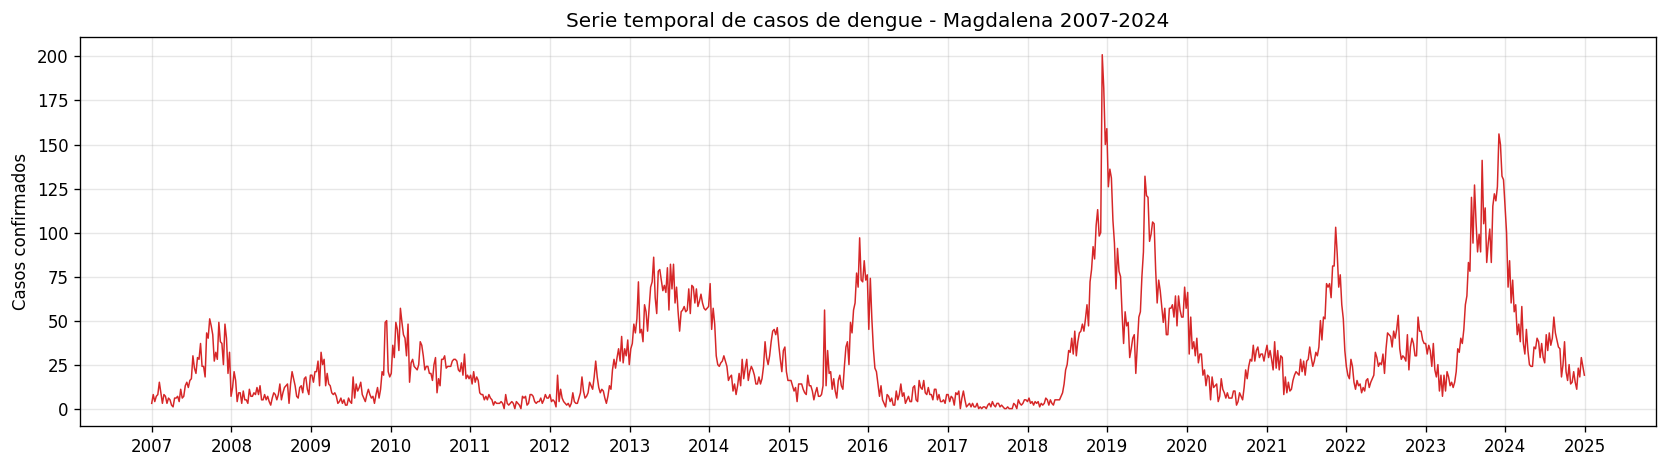

In [3]:
serie = df_dep.set_index('fecha_semana')['casos']


fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(serie.index, serie.values, color='#d62728', linewidth=0.9) #type: ignore
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylabel('Casos confirmados')
ax.set_title('Serie temporal de casos de dengue - Magdalena 2007-2024')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / 'serie_casos.png', dpi=150, bbox_inches='tight')
plt.show()

ay un patrón anual recurrente, no un ciclo limpio. Casi todos los años muestran una subida y una bajada dentro del año, lo cual confirma componente estacional anual (s=52). Pero la fecha del pico, la altura y hasta el número de picos cambian de un año a otro. Entre temporadas altas se observan períodos de baja transmisión con valores cercanos a cero por lo que porcederemos a estabilizar su varianza

## 2.2 Estabilidad de varianza con transformación log1p

Muchos modelos estadísticos asumen varianza constante (homocedasticidad); si la varianza crece junto con el nivel de casos, esa suposición se rompe. Primero se revisa la varianza móvil sobre una ventana de 12 semanas (un trimestre): si crece en los períodos de brote, hay heterocedasticidad. Luego se aplica la transformación log(1+x) (se usa 1+x porque la serie tiene semanas con cero casos) y se compara la estabilidad del coeficiente de variación móvil de ambas series para confirmar la mejora. El análisis de las secciones siguientes se hace sobre la serie ya transformada.

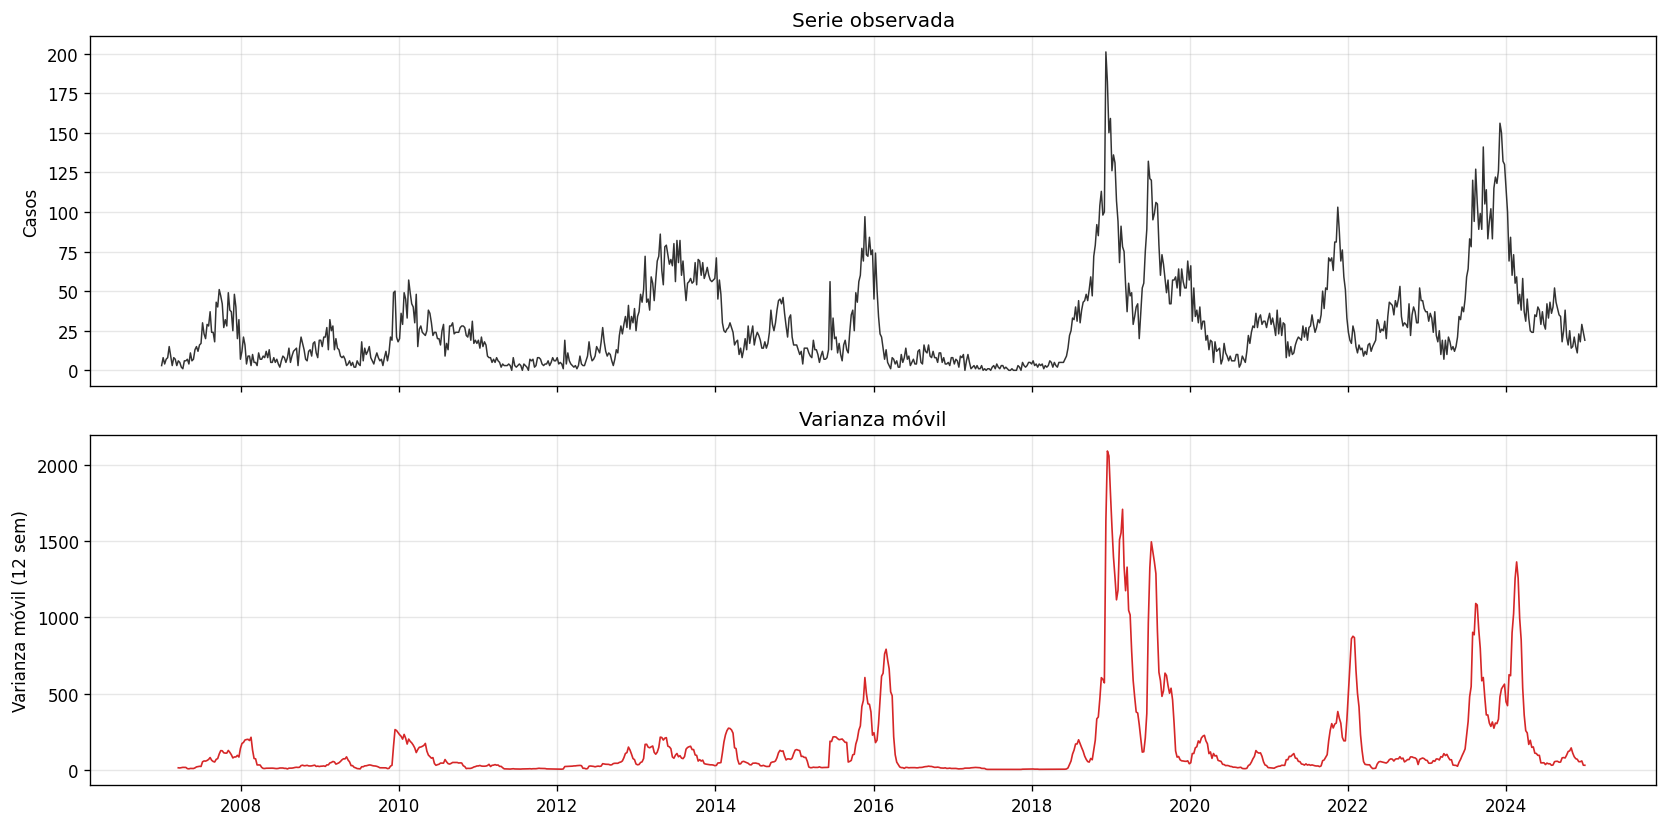

Varianza móvil mínima: 1.1
Varianza móvil máxima: 2093.9
Razón máx/mín: 1974.2


In [4]:
VENTANA = 12 
var_movil = serie.rolling(window=VENTANA).var()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(serie.index, serie.values, color='#333333', linewidth=0.9)
axes[0].set_ylabel('Casos')
axes[0].set_title('Serie observada')
axes[0].grid(alpha=0.3)

axes[1].plot(var_movil.index, var_movil.values, color='#d62728', linewidth=1.0)
axes[1].set_ylabel(f'Varianza móvil ({VENTANA} sem)')
axes[1].set_title('Varianza móvil')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / 'varianza_movil.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Varianza móvil mínima: {var_movil.min():.1f}')
print(f'Varianza móvil máxima: {var_movil.max():.1f}')
print(f'Razón máx/mín: {var_movil.max() / var_movil.min():.1f}')

La varianza móvil está lejos de ser constante, y cae casi a cero en los períodos de baja transmisión. La razón entre la varianza máxima y mínima supera ampliamente un orden de magnitud, lo que confirma que la serie es fuertemente heterocedástica: la dispersión crece con el nivel de casos. Esto viola el supuesto de varianza constante de los modelos estadísticos y justifica evaluar una transformación estabilizadora en la sección siguiente.

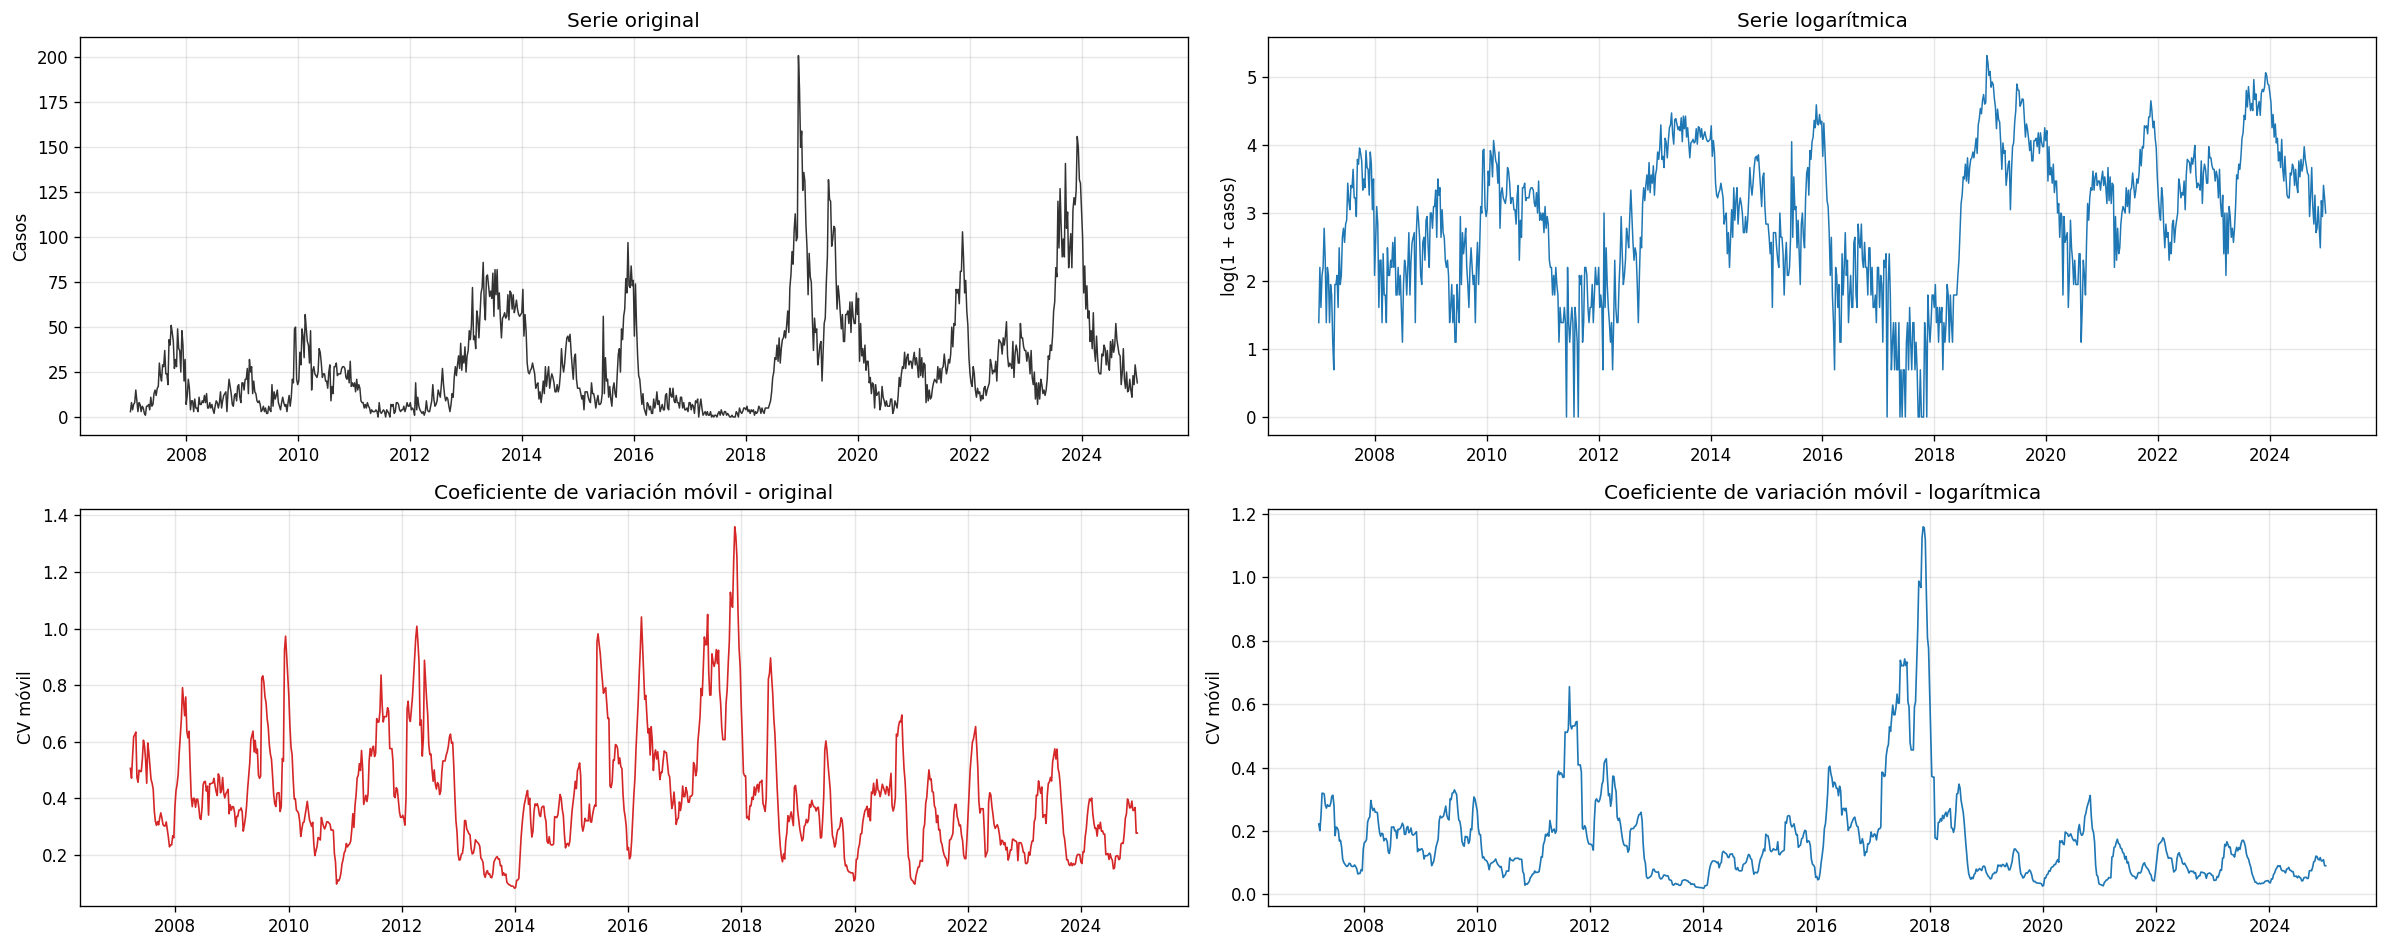

Varianza del CV móvil - original: 0.042198
Varianza del CV móvil - log: 0.024357
Reducción: 42%


In [5]:
serie_log = np.log1p(serie)

# Coeficiente de variacion movil: dispersion relativa a la media en cada ventana
def cv_movil(s, v=VENTANA):
    return (s.rolling(v).std() / s.rolling(v).mean()).dropna()

cv_orig = cv_movil(serie)
cv_log = cv_movil(serie_log)

fig, axes = plt.subplots(2, 2, figsize=(20, 8))

# Fila 1: serie original y serie logaritmica
axes[0, 0].plot(serie.index, serie.values, color='#333333', linewidth=0.9)
axes[0, 0].set_ylabel('Casos')
axes[0, 0].set_title('Serie original')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(serie_log.index, serie_log.values, color='#1f77b4', linewidth=0.9)
axes[0, 1].set_ylabel('log(1 + casos)')
axes[0, 1].set_title('Serie logarítmica')
axes[0, 1].grid(alpha=0.3)


# Fila 2: cv movil serie original y cv movil serie original logaritmica
axes[1, 0].plot(cv_orig.index, cv_orig.values, color='#d62728', linewidth=1.0)
axes[1, 0].set_ylabel('CV móvil')
axes[1, 0].set_title('Coeficiente de variación móvil - original')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(cv_log.index, cv_log.values, color='#1f77b4', linewidth=1.0)
axes[1, 1].set_ylabel('CV móvil')
axes[1, 1].set_title('Coeficiente de variación móvil - logarítmica')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS / 'comparacion_cv_movil.png', dpi=150, bbox_inches='tight')
plt.show()


print(f'Varianza del CV móvil - original: {cv_orig.var():.6f}')
print(f'Varianza del CV móvil - log: {cv_log.var():.6f}')
print(f'Reducción: {(1 - cv_log.var() / cv_orig.var()) * 100:.0f}%')

La varianza móvil de la sección anterior confirmó que la dispersión crece con el nivel de casos, pero no se puede usar directamente para comparar la serie original con la serie logarítmica ya que ambas están en escalas distintas (una en casos, la otra en log(1+casos)). Para hacer la comparación justa se usa el coeficiente de variación móvil (CV = desviación estándar / media), que es adimensional y elimina el efecto de la escala al expresar la dispersión como proporción de la media local.

La transformación logarítmica reduce la variabilidad del coeficiente de variación 
móvil respecto a la serie original, confirmando que estabiliza la dispersión. 
Adicionalmente, el patrón cíclico visible en el CV móvil de ambas series, con 
picos que se repiten aproximadamente cada 52 semanas evidencia una estacionalidad 
anual marcada, por lo que en la siguiente sección miraremos los componentes de la serie por separado para evaluar la presencia de estacionalidad.

## 2.3 Descomposición STL sobre la serie logarítmica

Se descompone la serie en tendencia, estacionalidad y ruido para entender su estructura. Conceptualmente una serie combina tendencia (comportamiento de fondo), ciclo (oscilaciones de duración variable), estacionalidad (patrón fijo, anual aquí) y ruido. En la práctica tendencia y ciclo se entregan juntos porque su separación no es identificable de forma única.

Se usa STL (Seasonal-Trend decomposition using Loess), que ajusta curvas locales suaves. Se elige sobre la descomposición clásica porque permite que el patrón estacional evolucione a lo largo de los años y es robusta frente a valores atípicos como los picos de brote. La descomposición se aplica sobre la serie logarítmica, como STL asume un modelo aditivo (Y = tendencia + estacionalidad + ruido) y la serie original es multiplicativa (la amplitud crece con el nivel), el logaritmo convierte esa relación multiplicativa en aditiva y hace válida la descomposición.

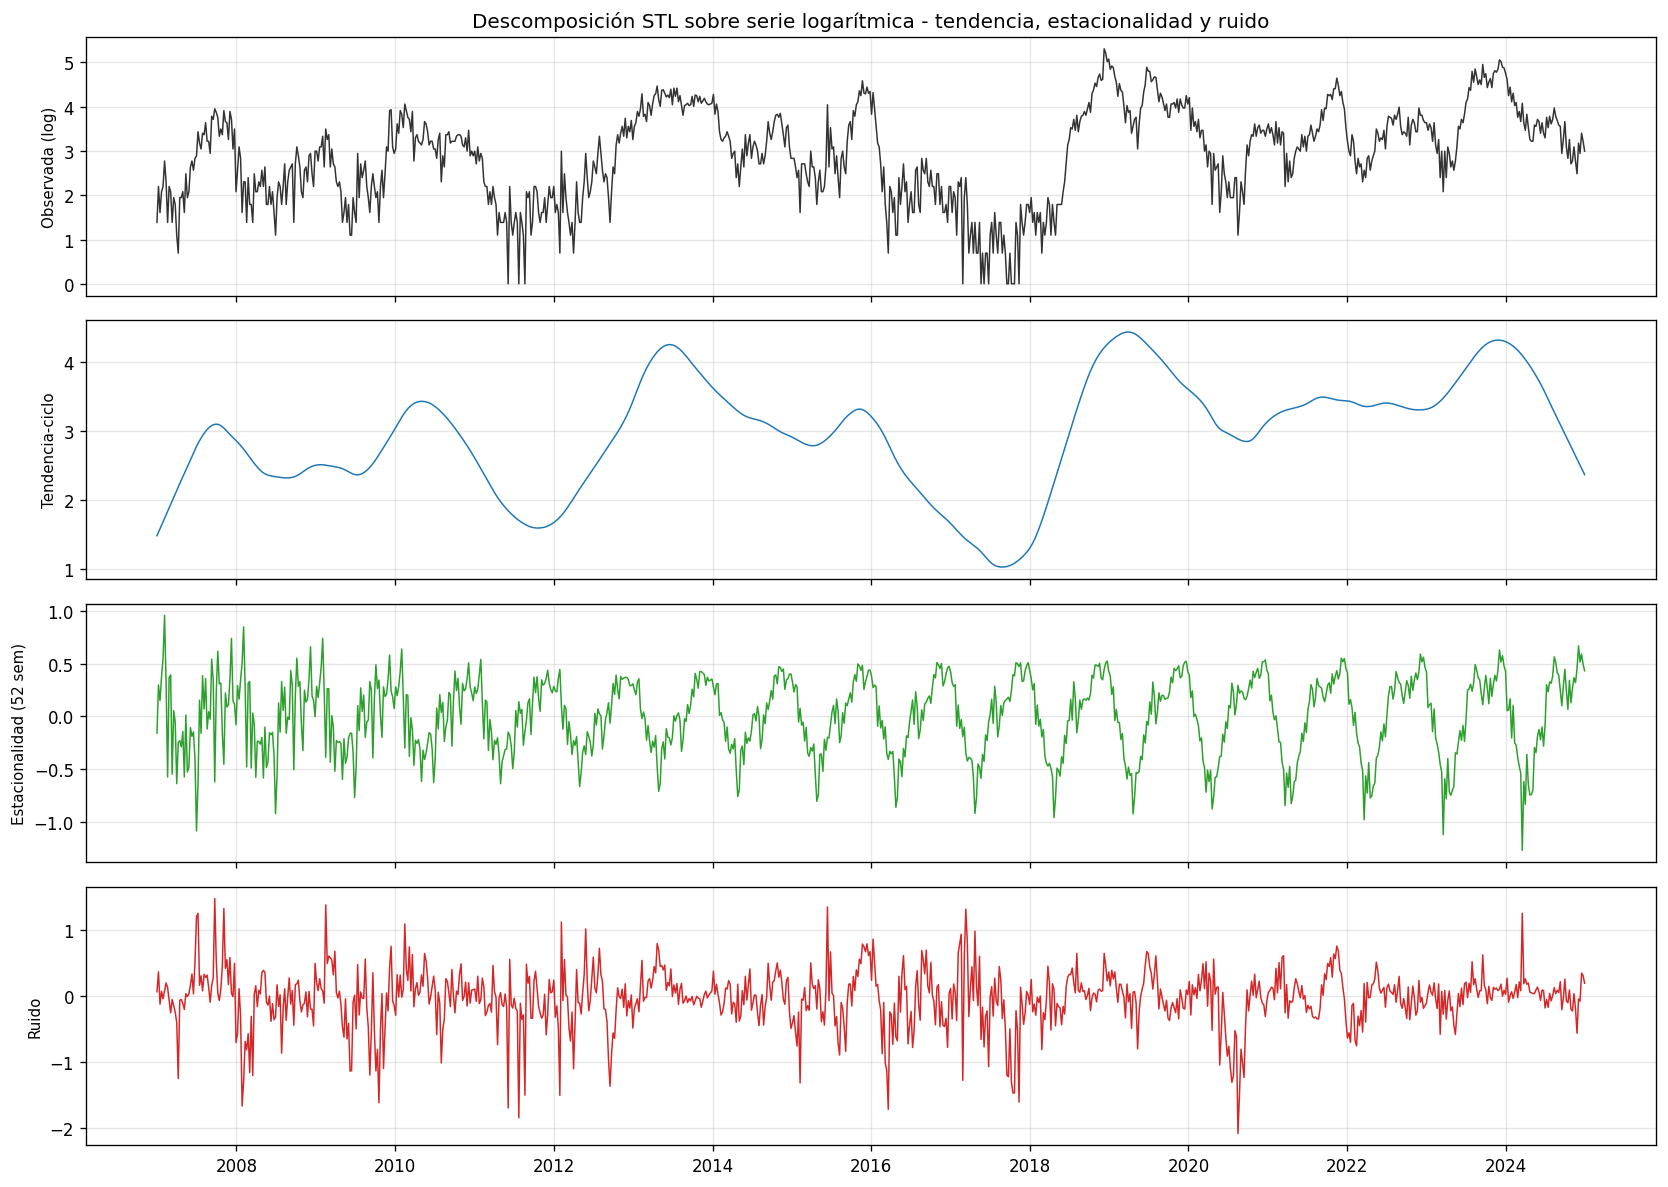

In [6]:
stl = STL(serie_log, period=52, seasonal=13, trend=53, robust=True).fit()
tendencia = stl.trend
estacionalidad = stl.seasonal
ruido = stl.resid

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
componentes = [
    (serie_log, 'Observada (log)', '#333333'),
    (tendencia, 'Tendencia-ciclo', '#1f77b4'),
    (estacionalidad, 'Estacionalidad (52 sem)', '#2ca02c'),
    (ruido, 'Ruido', '#d62728'),
]
for ax, (data, titulo, color) in zip(axes, componentes):
    ax.plot(data.index, data.values, color=color, linewidth=0.9)
    ax.set_ylabel(titulo, fontsize=9)
    ax.grid(alpha=0.3)
axes[0].set_title('Descomposición STL sobre serie logarítmica - tendencia, estacionalidad y ruido')
plt.tight_layout()
plt.savefig(OUTPUTS / 'descomposicion_serie.png', dpi=150, bbox_inches='tight')
plt.show()

La descomposición confirma una estacionalidad anual marcada y estable en su forma, con un ciclo de 52 semanas que se repite cada año, lo que respalda el uso de terminos estacionales en los modelos.

El residuo se mantiene centrado en cero y sin estructura estacional remanente, lo que indica que la descomposicion extrajo bien la componente anual. Sin embargo conserva una varianza considerable, con picos puntuales a lo largo de toda la serie atribuibles a brotes atipicos o anomalias de reporte. Esta varianza no explicada por tendencia y estacionalidad motiva la inclusion de covariables climaticas y terminos autorregresivos en el modelado. El tramo final de la tendencia muestra una caida pronunciada que podria estar influenciada por el efecto de borde del suavizado loess, dado que en los extremos de la serie hay menos datos disponibles.

Ahora evaluaremos si la serie es estacionaria.

## 2.4 Pruebas de estacionariedad (ADF, KPSS)

Una serie es estacionaria cuando sus propiedades estadísticas (media, varianza, autocorrelación) no cambian con el tiempo. La mayoría de modelos ARIMA exigen estacionariedad, por lo que se verifica y, si no se cumple, se aplica diferenciación.

Se usan dos pruebas complementarias. ADF (Augmented Dickey-Fuller) tiene como hipótesis nula que la serie NO es estacionaria; un p-valor menor a 0.05 permite concluir estacionariedad. KPSS tiene la hipótesis nula contraria; aquí un p-valor menor a 0.05 lleva a rechazar la estacionariedad. La conclusión más confiable se da cuando ambas coinciden. Las pruebas se aplican sobre la serie logarítmica, su diferencia regular y su diferencia estacional, para sustentar la elección de d y D con evidencia. Es importante distinguir estacionariedad de estacionalidad: ADF y KPSS detectan tendencia estocástica pero no miden el patrón estacional.

In [7]:
def run_adf(serie):
    stat, p, _, _, crit, _ = adfuller(serie.dropna(), autolag='AIC')  # type: ignore
    return p, ('Estacionaria' if p < 0.05 else 'No estacionaria')

def run_kpss(serie):
    stat, p, _, crit = kpss(serie.dropna(), regression='c', nlags='auto')
    return p, ('No estacionaria' if p < 0.05 else 'Estacionaria')

def evaluar(serie, nombre):
    p_adf, c_adf = run_adf(serie)
    p_kpss, c_kpss = run_kpss(serie)
    return {
        'Serie': nombre,
        'ADF p-valor': round(p_adf, 4), 'ADF': c_adf,  # type: ignore
        'KPSS p-valor': round(p_kpss, 4), 'KPSS': c_kpss,
        'Estacionaria (ambas)': (c_adf == 'Estacionaria') and (c_kpss == 'Estacionaria'),
    }

# Se evalua la serie log sin diferenciar, con diferencia regular y con diferencia estacional
# para sustentar la eleccion de d y D con evidencia, no a priori.
df_stationarity = pd.DataFrame([
    evaluar(serie_log, 'Log sin diferenciar'),
    evaluar(serie_log.diff(), 'Log diff regular (d=1)'),
])
print(df_stationarity.to_string(index=False))

                 Serie  ADF p-valor          ADF  KPSS p-valor            KPSS  Estacionaria (ambas)
   Log sin diferenciar       0.0014 Estacionaria        0.0107 No estacionaria                 False
Log diff regular (d=1)       0.0000 Estacionaria        0.1000    Estacionaria                  True


Las pruebas confirman que la serie log no es estacionaria por lo que se aplicara la primera diferenciacion (d=1).

## 2.5 ACF / PACF - identificación de órdenes

Se analiza la estructura de autocorrelación de la serie logarítmica para orientar la selección de los órdenes p, q, P y Q. La ACF (Función de Autocorrelación) mide la correlación de la serie con versiones retrasadas de sí misma y orienta los órdenes de media móvil q y Q. La PACF (Función de Autocorrelación Parcial) mide la correlación con cada lag eliminando el efecto de los intermedios y orienta los órdenes autorregresivos p y P.

In [8]:
serie_log_diff = serie_log.diff()

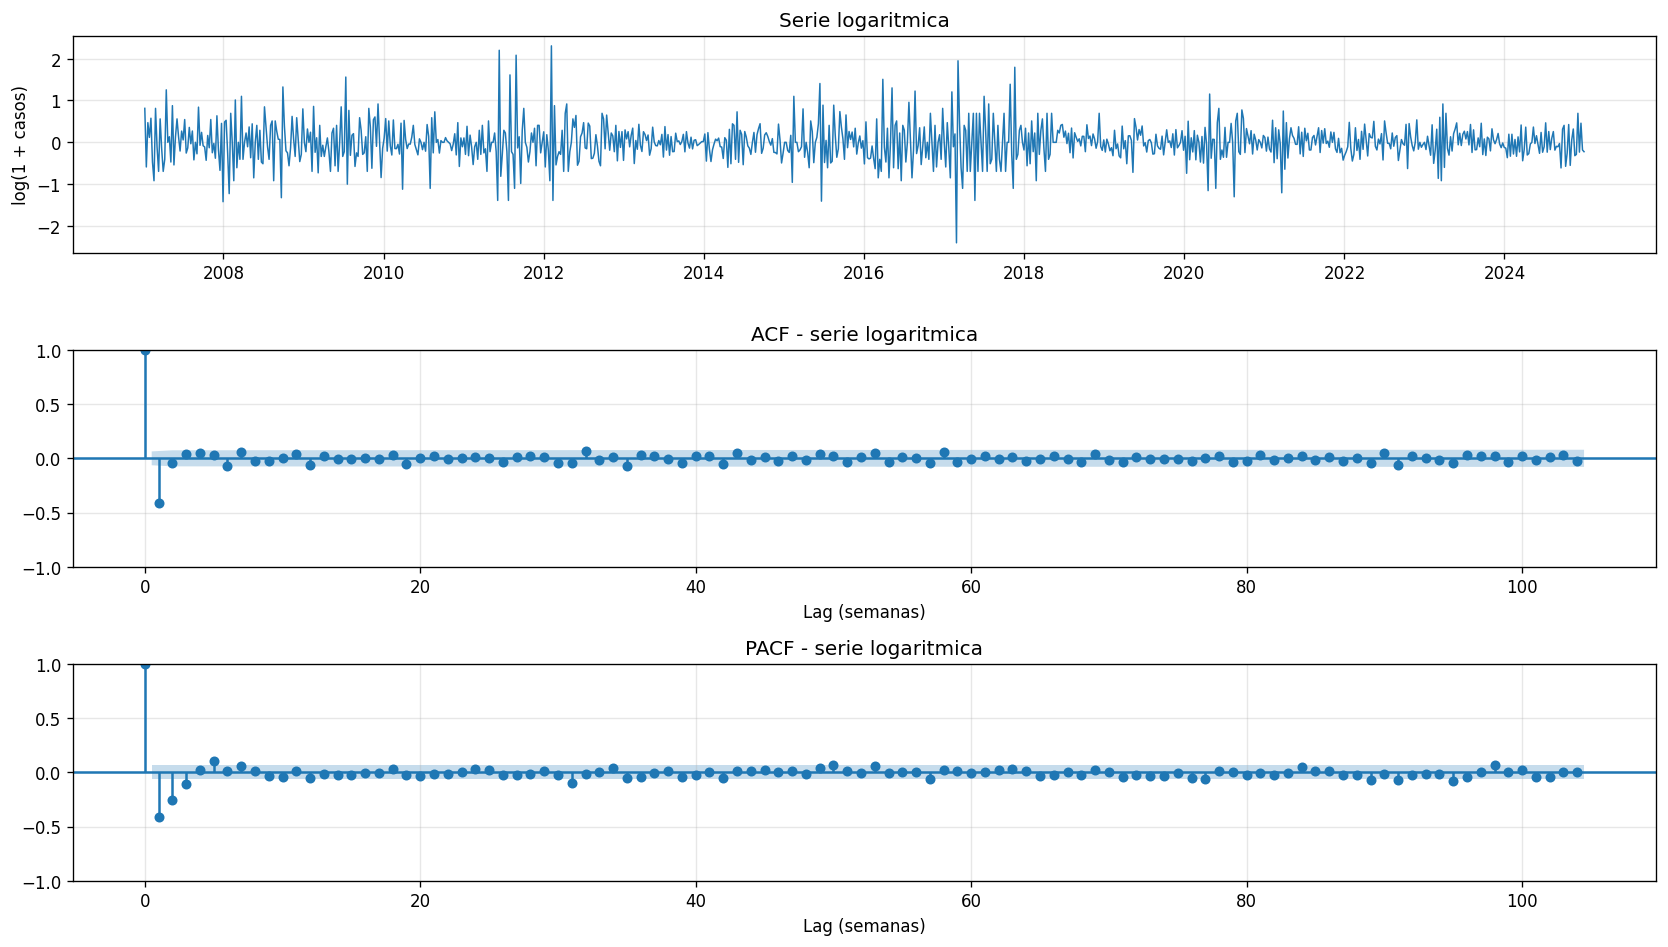

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

# subplot 0 - serie original
axes[0].plot(serie_log_diff.index, serie_log_diff.values, color='#1f77b4', linewidth=0.9)
axes[0].set_ylabel('log(1 + casos)')
axes[0].set_title('Serie logaritmica')
axes[0].grid(alpha=0.3)

# subplot 1 - ACF
plot_acf(serie_log_diff.dropna(), lags=104, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF - serie logaritmica')
axes[1].set_xlabel('Lag (semanas)')
axes[1].grid(alpha=0.3)

# subplot 2 - PACF
plot_pacf(serie_log_diff.dropna(), lags=104, ax=axes[2], alpha=0.05, method='ywm')
axes[2].set_title('PACF - serie logaritmica')
axes[2].set_xlabel('Lag (semanas)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS / 'acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

La PACF presenta 4 rezagos significativos (lag 1 cercano a -0.5, lag 2 alrededor de -0.3, lag 3 -0.1 y lag 5 0.1)por lo que se fija p = [1,2,3,5]. La ACF decae con un corte abrupto en el lag 1, por lo que se parte de q = 1. Las pruebas de la sección 2.4 ya confirmaron estacionariedad con la primera diferenciacion, de modo que d = 1.

Para los ordenes estacionales, ni ACF ni PACF muestran picos aislados significativos en los multiplos de 52 por lo que P = 0 y Q = 0. El periodo estacional se fija en s = 52, correspondiente al ciclo anual de semanas epidemiologicas, y se incorpora mediante la extension estacional del modelo, es decir SARIMA(p,d,q)(P,D,Q,52), y no mediante un ARIMA simple.

El ciclo anual del dengue de 52 semanas está documentado en la literatura. Zhao et al., trabajando con datos de SIVIGILA en Colombia, incorporan el número ordinal de semana epidemiológica (1 a 52) como predictor explícito para capturar la estacionalidad de la transmisión. Sobre esta base, el componente estacional se incluye en el modelo por justificación epidemiológica y por la evidencia de la descomposición, y no únicamente por el correlograma, cuya capacidad para exhibir estructura estacional es limitada en series cortas con autocorrelación de corto plazo dominante.

Los valores p = [1,2,3,5], q = 1, P = 0, Q = 0 y s = 52 constituyen el punto de partida obtenido por identificación manual. En la seccion 4 se usa auto_arima, con d = 1 y D = 0 fijos segun lo confirmado en la seccion 2.4 y s = 52 fijo, para explorar de forma sistematica el espacio de ordenes alrededor de esta propuesta y confirmar o ajustar p, q, P y Q con base en un criterio de informacion (AIC o BIC).

# 3 Division temporal train / val / test

La serie se divide en tres bloques cronologicos contiguos respetando el orden temporal, sin barajar. El primer 70 por ciento es entrenamiento, el 15 por ciento siguiente es validacion y el 15 por ciento final es prueba. El conjunto de prueba es el mismo para todos los modelos y solo se usa una vez por modelo, lo que mantiene la comparacion de la seccion 7 libre de fuga de informacion.

El conjunto de validacion no lo necesitan todos los modelos por igual. SARIMAX y Prophet fijan su estructura por criterios de informacion, no por una busqueda sobre validacion, y los modelos de arboles seleccionan sus hiperparametros con validacion cruzada temporal sobre el bloque de entrenamiento ampliado. Por eso estos cuatro modelos entrenan con train mas val (85 por ciento) y predicen el test, lo que ademas evita un hueco temporal entre el fin del entrenamiento y el inicio del test. La validacion separada solo la usan las redes neuronales (seccion 6) para el early stopping.

Train:  658 sem (2006-2019) | 70.0%
Val  :  141 sem (2019-2022) | 15.0%
Test :  141 sem (2022-2024) | 15.0%
Train+Val:  799 sem | 85.0%


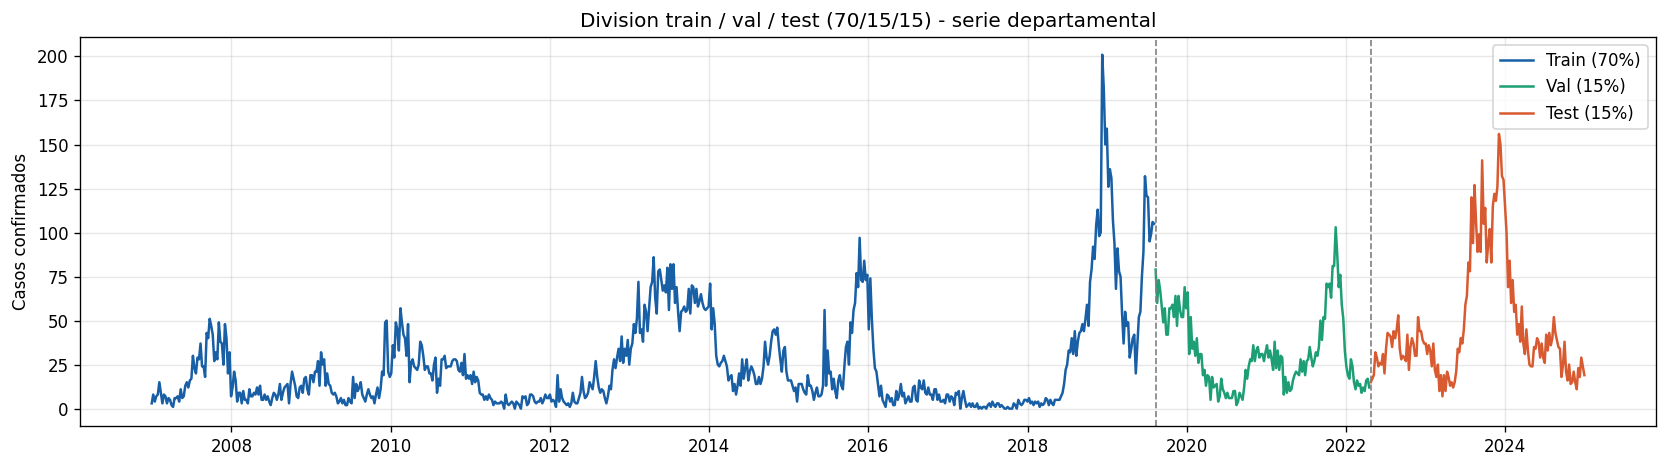

In [10]:
TRAIN_FRAC, TEST_FRAC = 0.70, 0.30
n = len(df_dep)
n_resto = round(n * TEST_FRAC)

idx_train, idx_resto = list(TimeSeriesSplit(n_splits=2, test_size=n_resto).split(df_dep))[-1]

df_train_dep = df_dep.iloc[idx_train].copy()
df_resto = df_dep.iloc[idx_resto].copy()

# El 30% restante se parte en dos mitades cronologicas iguales: validacion y test.
n_val = len(df_resto) // 2
df_val_dep = df_resto.iloc[:n_val].copy()
df_test_dep = df_resto.iloc[n_val:].copy()

# Conjuntos de fechas para alinear cualquier dataset derivado de df_dep.
FECHAS_TRAIN = set(df_train_dep['fecha_semana'])
FECHAS_VAL = set(df_val_dep['fecha_semana'])
FECHAS_TEST = set(df_test_dep['fecha_semana'])

# train + val (85%): bloque de entrenamiento para los modelos que no reservan
# una validacion aparte. Llega contiguo hasta justo antes del test.
df_trainval_dep = pd.concat([df_train_dep, df_val_dep]).sort_values('fecha_semana')
FECHAS_TRAINVAL = FECHAS_TRAIN | FECHAS_VAL

for nombre, d in [('Train', df_train_dep), ('Val', df_val_dep), ('Test', df_test_dep)]:
    print(f'{nombre:5s}: {len(d):4d} sem ({d["fecha_semana"].dt.year.min()}-{d["fecha_semana"].dt.year.max()}) | {len(d) / n:.1%}')
print(f'Train+Val: {len(df_trainval_dep):4d} sem | {len(df_trainval_dep) / n:.1%}')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_train_dep['fecha_semana'], df_train_dep['casos'], color='#185FA5', label='Train (70%)')
ax.plot(df_val_dep['fecha_semana'], df_val_dep['casos'], color='#1D9E75', label='Val (15%)')
ax.plot(df_test_dep['fecha_semana'], df_test_dep['casos'], color='#D85A30', label='Test (15%)')
ax.axvline(df_val_dep['fecha_semana'].iloc[0], color='gray', linewidth=1, linestyle='--')
ax.axvline(df_test_dep['fecha_semana'].iloc[0], color='gray', linewidth=1, linestyle='--')
ax.set_ylabel('Casos confirmados')
ax.set_title('Division train / val / test (70/15/15) - serie departamental')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / 'train_val_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

# 4 Modelos estadísticos

Este bloque agrupa los modelos estadísticos clásicos de series de tiempo. La familia ARIMA combina tres componentes: una parte autorregresiva (AR) que usa los valores pasados de la serie, una parte de integración o diferenciación (I) que elimina tendencias para alcanzar estacionariedad, y una parte de media móvil (MA) que usa los errores pasados. Sus extensiones añaden capacidades: SARIMA incorpora una componente estacional con período fijo, y SARIMAX agrega además variables exógenas (la X de eXogenous), predictores externos que influyen en la serie sin formar parte de ella.

A partir del análisis de la sección 2 (estacionariedad confirmada con d = 1, estacionalidad anual respaldada por la descomposición STL y la literatura, y disponibilidad de variables climáticas) se trabaja directamente con SARIMAX como modelo de esta familia, por ser la formulación que aprovecha toda la estructura encontrada. Se complementa con Prophet, un modelo de naturaleza distinta que sirve como comparador.

Los modelos estadísticos reciben como entrada la serie logarítmica serie_log. 
La diferenciación de orden d=1 se aplica internamente por statsmodels y se 
revierte automáticamente en el forecast. Las predicciones se transforman a 
escala de casos con np.expm1 antes de calcular las métricas, de modo que los errores se reporten en la unidad interpretable (casos).

## 4.1 Familia ARIMA y extensiones: SARIMAX

La eleccion de SARIMAX se sustenta en lo encontrado a lo largo del analisis. Las pruebas ADF y KPSS de la seccion 2.4 confirmaron que la serie logaritmica se vuelve estacionaria al aplicar la primera diferenciacion, por lo que se fija d = 1. La lectura de la PACF acota el orden autorregresivo y la de la ACF sugiere el orden de media movil como punto de partida. La estacionalidad anual, no visible en el correlograma por las razones expuestas en 2.5 pero clara en la descomposicion STL y documentada por Zhao et al. para datos de SIVIGILA en Colombia, se modela con los terminos estacionales sobre un periodo s = 52, sin diferenciacion estacional (D = 0).

El uso de variables exogenas climaticas sigue la formulacion de SARIMAX descrita por Chen y Moraga, donde temperatura y humedad entran como covariables del modelo de dengue. El clima no actua de forma instantanea sobre la transmision: existe un retardo entre la variacion climatica y el cambio en los casos, asociado al ciclo del vector y al periodo de incubacion. Por ello las variables exogenas se incorporan rezagadas, en el rango de 1 a 4 semanas documentado en la literatura.

SARIMAX y Prophet entrenan con el bloque train mas val (85 por ciento) y pronostican el test (15 por ciento final). No usan el conjunto de validacion por separado porque sus ordenes se eligen por criterio de informacion y no por una busqueda sobre validacion. Entrenar con train mas val mantiene el origen del pronostico contiguo al test y evita el hueco temporal que degradaria un pronostico autorregresivo de horizonte largo.

### Tratamiento de las variables exógenas

SARIMAX exige que las variables exógenas también sean estacionarias para que sus coeficientes sean válidos. Por ello, antes de incorporarlas, cada una de las cinco variables climáticas (humedad, precipitación, t2m_max, t2m_media, t2m_min) recibe el mismo diagnóstico que se aplicó a la serie de casos: se evalúa la estabilidad de su varianza mediante el coeficiente de variación móvil y se comprueba su estacionariedad con las pruebas ADF y KPSS. La tabla resume ambos diagnósticos para decidir, variable por variable, si requiere alguna transformación o diferenciación antes de entrar al modelo.

        Serie  CV movil var  ADF p-valor          ADF  KPSS p-valor            KPSS  Estacionaria (ambas)
      humedad      0.001201       0.0000 Estacionaria        0.0242 No estacionaria                 False
precipitacion      0.148066       0.0000 Estacionaria        0.1000    Estacionaria                  True
      t2m_max      0.000090       0.0000 Estacionaria        0.0100 No estacionaria                 False
    t2m_media      0.000040       0.0003 Estacionaria        0.0100 No estacionaria                 False
      t2m_min      0.000028       0.0000 Estacionaria        0.0193 No estacionaria                 False


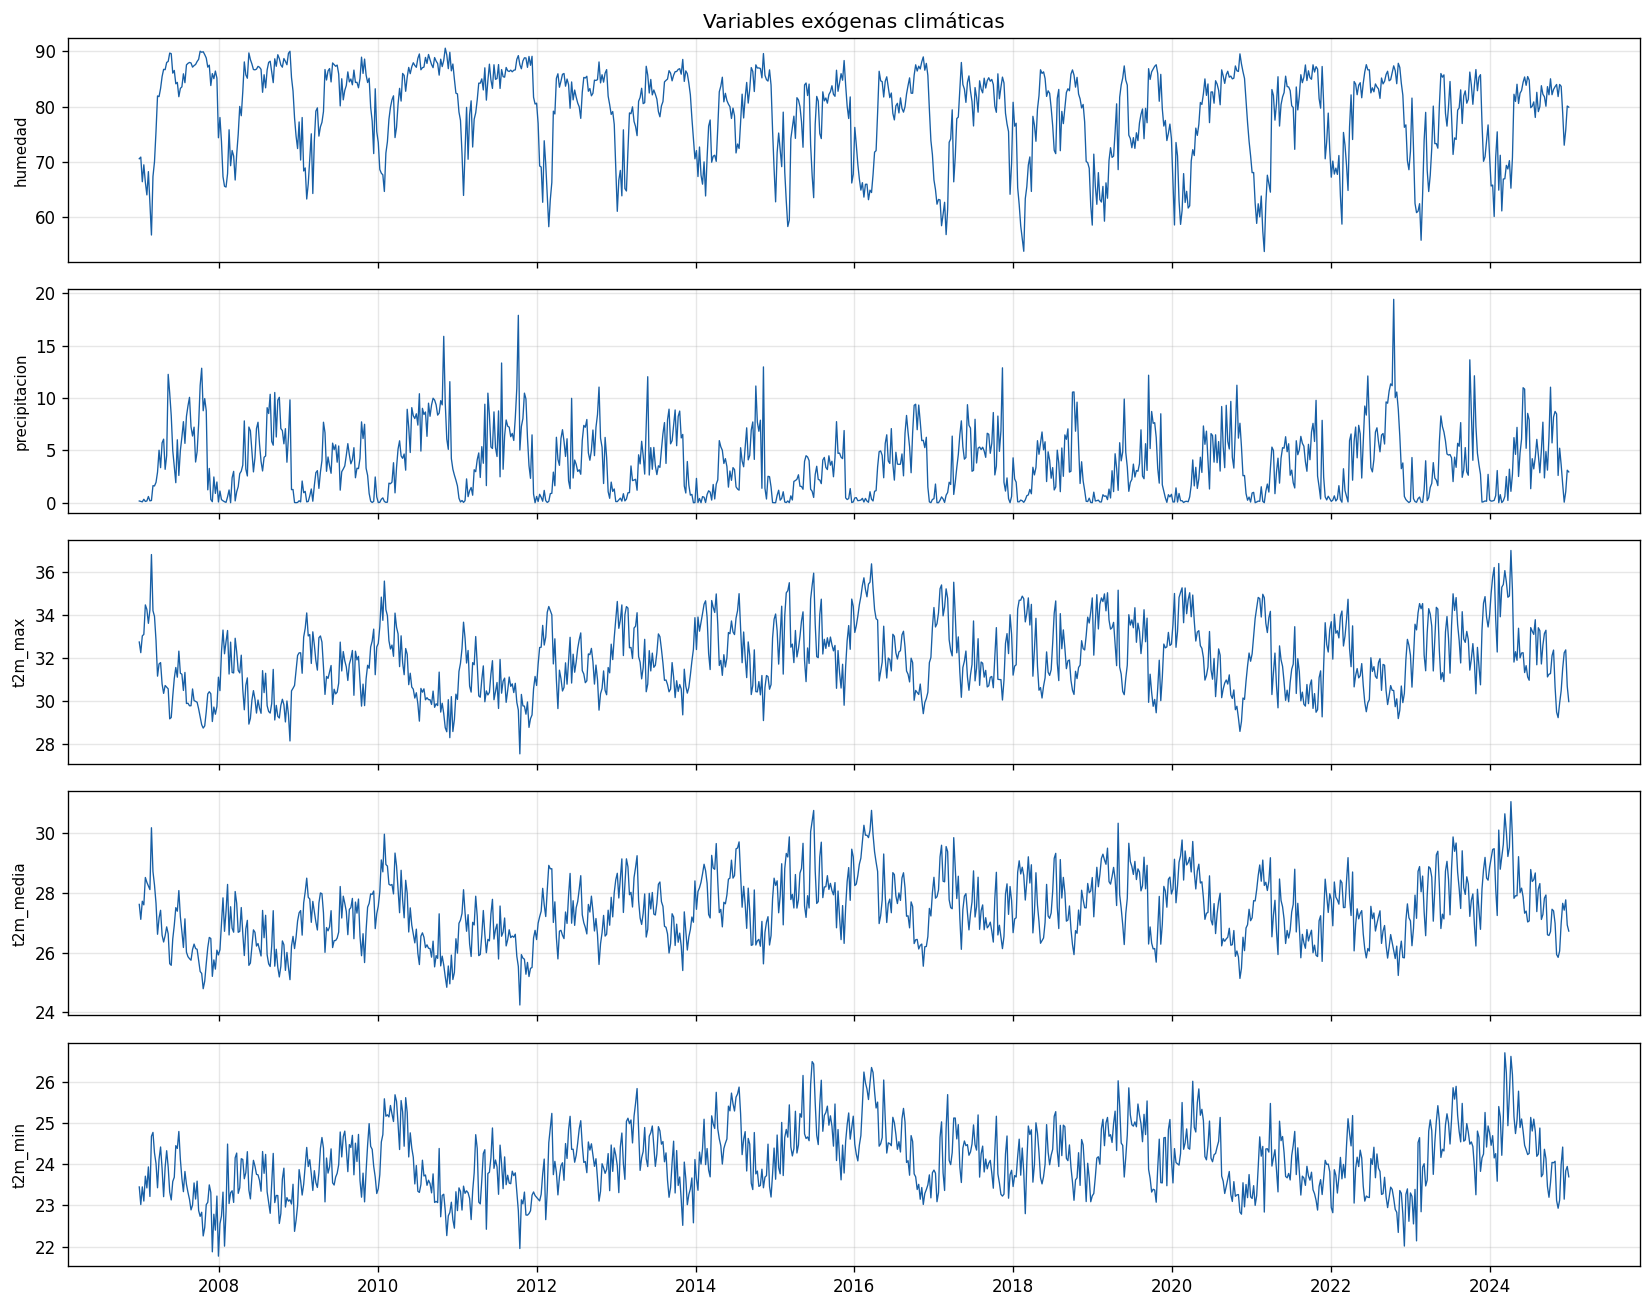

In [11]:
CLIMA_EXOG = ['humedad', 'precipitacion', 't2m_max', 't2m_media', 't2m_min']

serie_exog = df_dep.set_index('fecha_semana')[CLIMA_EXOG]

filas_diag = []
for var in CLIMA_EXOG:
    s = serie_exog[var]
    cv = cv_movil(s)
    fila = evaluar(s, var)
    fila['CV movil var'] = round(float(cv.var()), 6)
    filas_diag.append(fila)

df_diag_exog = pd.DataFrame(filas_diag)[
    ['Serie', 'CV movil var', 'ADF p-valor', 'ADF', 'KPSS p-valor', 'KPSS', 'Estacionaria (ambas)']
]
print(df_diag_exog.to_string(index=False))

# Visualizacion de las cinco series climaticas
fig, axes = plt.subplots(5, 1, figsize=(14, 11), sharex=True)
for ax, var in zip(axes, CLIMA_EXOG):
    ax.plot(serie_exog.index, serie_exog[var], color='#185FA5', linewidth=0.8)
    ax.set_ylabel(var, fontsize=9)
    ax.grid(alpha=0.3)
axes[0].set_title('Variables exógenas climáticas')
plt.tight_layout()
plt.savefig(OUTPUTS / 'exogenas_climaticas.png', dpi=150, bbox_inches='tight')
plt.show()

El coeficiente de variacion movil revela que precipitacion presenta una varianza notablemente menos estable que las demas variables (0.148 frente a valores entre 0.00003 y 0.001 en humedad y las variables de temperatura), un patron similar al observado en la serie de casos antes de su transformacion logaritmica. Por esta razon se aplica log1p a precipitacion, evitando el problema de valores cero presentes en los registros semanales de lluvia.

Las pruebas de estacionariedad muestran un panorama distinto al de la varianza: precipitacion es la unica variable que satisface ADF y KPSS de forma conjunta sin transformar. Las cuatro variables restantes (humedad, t2m_max, t2m_media, t2m_min) tienen varianza estable pero ADF y KPSS no coinciden entre si (ADF concluye estacionariedad mientras KPSS la rechaza, con p-valores entre 0.01 y 0.0242), lo que es evidencia de una tendencia estocastica residual en la media. Por eso se les aplica una diferenciacion regular, que corrige la media sin necesidad de tocar la varianza, ya estable en su escala original.

In [12]:
VARS_DIFERENCIAR = ['humedad', 't2m_max', 't2m_media', 't2m_min']

serie_precip_log = np.log1p(serie_exog['precipitacion'])

series_diff = {}
filas = [evaluar(serie_precip_log, 'precipitacion_log')]
for var in VARS_DIFERENCIAR:
    serie_diff = serie_exog[var].diff()
    series_diff[f'{var}_diff'] = serie_diff
    filas.append(evaluar(serie_diff, f'{var}_diff'))

df_diag_transformadas = pd.DataFrame(filas)[
    ['Serie', 'ADF p-valor', 'ADF', 'KPSS p-valor', 'KPSS', 'Estacionaria (ambas)']
]
print(df_diag_transformadas.to_string(index=False))


            Serie  ADF p-valor          ADF  KPSS p-valor         KPSS  Estacionaria (ambas)
precipitacion_log          0.0 Estacionaria           0.1 Estacionaria                  True
     humedad_diff          0.0 Estacionaria           0.1 Estacionaria                  True
     t2m_max_diff          0.0 Estacionaria           0.1 Estacionaria                  True
   t2m_media_diff          0.0 Estacionaria           0.1 Estacionaria                  True
     t2m_min_diff          0.0 Estacionaria           0.1 Estacionaria                  True


### Combinaciones de exógenas a experimentar

Se prueban distintos subconjuntos de variables climáticas para identificar cuál aporta mayor capacidad predictiva, evitando la redundancia entre las tres medidas de temperatura (máxima, media y mínima), que están fuertemente correlacionadas entre sí. Cada configuración se entrena con los mismos órdenes regulares y estacionales y se registra como un experimento independiente en MLflow

El conjunto sin exógenas (equivalente a un SARIMA puro) se incluye como referencia para cuantificar el aporte real del clima.

### Pipeline de datos y funcion de experimentacion

Para no repetir el tratamiento en cada experimento se definen dos funciones. La primera, preparar_datos_sarimax, construye los rezagos de las exogenas indicadas, transforma la serie de casos a escala logaritmica, y separa el bloque de entrenamiento (train mas val) del bloque de prueba segun los conjuntos de fechas de la seccion 3. La segunda, correr_sarimax, recibe la lista de exogenas y los ordenes, ajusta el modelo sobre la serie logaritmica de entrenamiento, revierte la prediccion a escala de casos con np.expm1, calcula las metricas sobre el test, grafica y registra todo en MLflow. El nombre de cada corrida se deriva de la lista de exogenas para que MLflow quede trazable sin etiquetas escritas a mano.

In [42]:
LAG_EXOG = 2

def preparar_datos_sarimax(exog_vars, fechas_entreno, fechas_test, lag=LAG_EXOG):
    cols_exog = [f'{v}_lag{lag}' for v in exog_vars]

    base = df_dep.copy()
    for v in exog_vars:
        if v == 'precipitacion_log':
            serie_base = np.log1p(base['precipitacion'])
        elif v.endswith('_diff'):
            var_raw = v.replace('_diff', '')
            serie_base = base[var_raw].diff()
        else:
            serie_base = base[v]
        base[f'{v}_lag{lag}'] = serie_base.shift(lag)

    base['casos_log'] = np.log1p(base['casos'])

    if cols_exog:
        base = base.dropna(subset=cols_exog)
    base = base.set_index('fecha_semana')

    entreno = base[base.index.isin(fechas_entreno)]
    test = base[base.index.isin(fechas_test)]

    y_entreno_log = entreno['casos_log']
    y_test_log = test['casos_log']
    y_test_real = test['casos']
    X_entreno = entreno[cols_exog] if cols_exog else None
    X_test = test[cols_exog] if cols_exog else None

    return y_entreno_log, y_test_log, y_test_real, X_entreno, X_test, cols_exog


def nombre_run_sarimax(exog_vars):
    if not exog_vars:
        return 'SARIMAX_SIN_EXOG'
    return 'SARIMAX_' + '_'.join(v.upper() for v in exog_vars)


def correr_sarimax(exog_vars, order, seasonal_order, fechas_entreno, fechas_test, color='#9467bd'):
    run_name = nombre_run_sarimax(exog_vars)
    y_entreno_log, y_test_log, y_test_real, X_entreno, X_test, cols_exog = preparar_datos_sarimax(
        exog_vars, fechas_entreno, fechas_test)

    exog_entreno_arr = X_entreno.values if X_entreno is not None else None
    exog_test_arr = X_test.values if X_test is not None else None

    with mlflow.start_run(run_name=run_name):
        # Se estiman los parametros solo con el entrenamiento.
        fit = SARIMAX(
            y_entreno_log,
            exog=exog_entreno_arr,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)

        # Se extiende el modelo al tramo de test con los parametros ya fijos
        # (refit=False) y se piden las predicciones de un paso adelante sobre
        # ese tramo. dynamic=False hace que cada semana se prediga usando el
        # valor real de la anterior, igual que casos_lag1 en XGBoost y LSTM.
        modelo_test = fit.append(y_test_log, exog=exog_test_arr, refit=False)
        pred_log = modelo_test.predict(
            start=y_test_log.index[0],
            end=y_test_log.index[-1],
            exog=exog_test_arr,
            dynamic=False,
        )

        pred = pd.Series(np.expm1(pred_log), index=y_test_real.index).clip(lower=0)

        m = compute_metrics(y_test_real, pred)
        mlflow.log_params({
            'order': str(order), 'seasonal_order': str(seasonal_order),
            'exog': ','.join(exog_vars) if exog_vars else 'ninguna',
            'exog_cols': ','.join(cols_exog) if cols_exog else 'ninguna',
            'lag_exog': LAG_EXOG, 'escala_entrenamiento': 'log1p',
            'entrenamiento': 'train+val', 'pronostico': 'rodante-1-paso',
        })
        mlflow.log_metrics(m)

        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(y_entreno_log.index[-52:], np.expm1(y_entreno_log).iloc[-52:],
                color='#185FA5', label=f'Entrenamiento (ultimo año de {len(y_entreno_log)} sem.)')
        ax.plot(y_test_real.index, y_test_real.values, color='black', label='Real (test)')
        ax.plot(pred.index, pred.values, color=color, linestyle='--', label=run_name)
        ax.set_title(f'{run_name} - RMSE={m["RMSE"]} | MAE={m["MAE"]} | MAPE={m["MAPE"]}% | R2={m["R2"]}')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        plt.tight_layout()
        fig_path = OUTPUTS / f'{run_name}.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        mlflow.log_artifact(str(fig_path))
        plt.show()

    print_metrics(run_name, m)
    return run_name, m

### Seleccion de ordenes con auto_arima

En lugar de fijar los ordenes leyendo cada barra del correlograma (lo que en una serie con autocorrelacion fuerte lleva a sobreparametrizar, porque muchos cruces de la banda son inercia del proceso y no estructura real), se usa auto_arima para buscar los ordenes que minimizan el criterio de informacion.

Se fija D = 0 segun las pruebas de estacionariedad y se deja d = 1 confirmado por ADF y KPSS, acotando los rangos de p, q, P y Q. La busqueda se hace sobre la serie logaritmica de train mas val, sin exogenas, para aislar la seleccion de la estructura temporal; las exogenas se añaden despues en los experimentos. Como la busqueda con periodo estacional 52 es costosa, los rangos estacionales se mantienen pequeños. Una vez ejecutada, se leen los ordenes resultantes y se copian manualmente a las constantes ORDER y SEASONAL_ORDER de la celda de experimentos.

In [14]:
serie_log_entreno = np.log1p(df_trainval_dep.set_index('fecha_semana')['casos'])

modelo_auto = auto_arima(
    serie_log_entreno,
    seasonal=True, m=52,
    d=1, D=0,
    start_p=1, max_p=5,
    start_q=1, max_q=3,
    max_P=1, max_Q=1,
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True,
)

print()
print(modelo_auto.summary())
print()
print('Orden regular (p, d, q):', modelo_auto.order)
print('Orden estacional (P, D, Q, s):', modelo_auto.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[52] intercept   : AIC=inf, Time=30.08 sec
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=1120.296, Time=0.14 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=978.413, Time=4.69 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=920.056, Time=5.29 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=1118.304, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[52] intercept   : AIC=918.748, Time=0.30 sec
 ARIMA(0,1,1)(1,0,0)[52] intercept   : AIC=920.095, Time=8.08 sec
 ARIMA(0,1,1)(1,0,1)[52] intercept   : AIC=inf, Time=12.76 sec
 ARIMA(1,1,1)(0,0,0)[52] intercept   : AIC=919.574, Time=0.23 sec
 ARIMA(0,1,2)(0,0,0)[52] intercept   : AIC=918.856, Time=0.20 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=976.732, Time=0.16 sec
 ARIMA(1,1,2)(0,0,0)[52] intercept   : AIC=909.646, Time=0.52 sec
 ARIMA(1,1,2)(1,0,0)[52] intercept   : AIC=911.290, Time=11.74 sec
 ARIMA(1,1,2)(0,0,1)[52] intercept   : AIC=911.266, Time=13.86 sec
 ARIMA(1,1,2)(1,0,1)[52] intercept 

### Experimentos SARIMAX

Con los ordenes ya seleccionados por auto_arima (copiados manualmente en las constantes de abajo), se prueban las distintas combinaciones de variables exogenas. Todas las corridas comparten los mismos ordenes regulares y estacionales, de modo que la unica diferencia entre experimentos es el subconjunto de variables climaticas. Cada corrida entrena con train mas val, se evalua sobre el test y se registra en MLflow.

TODO: tras ejecutar auto_arima, copiar sus ordenes en ORDER y SEASONAL_ORDER. Tras correr los experimentos, revisar en MLflow cual combinacion de exogenas minimiza el RMSE y documentar la configuracion ganadora.

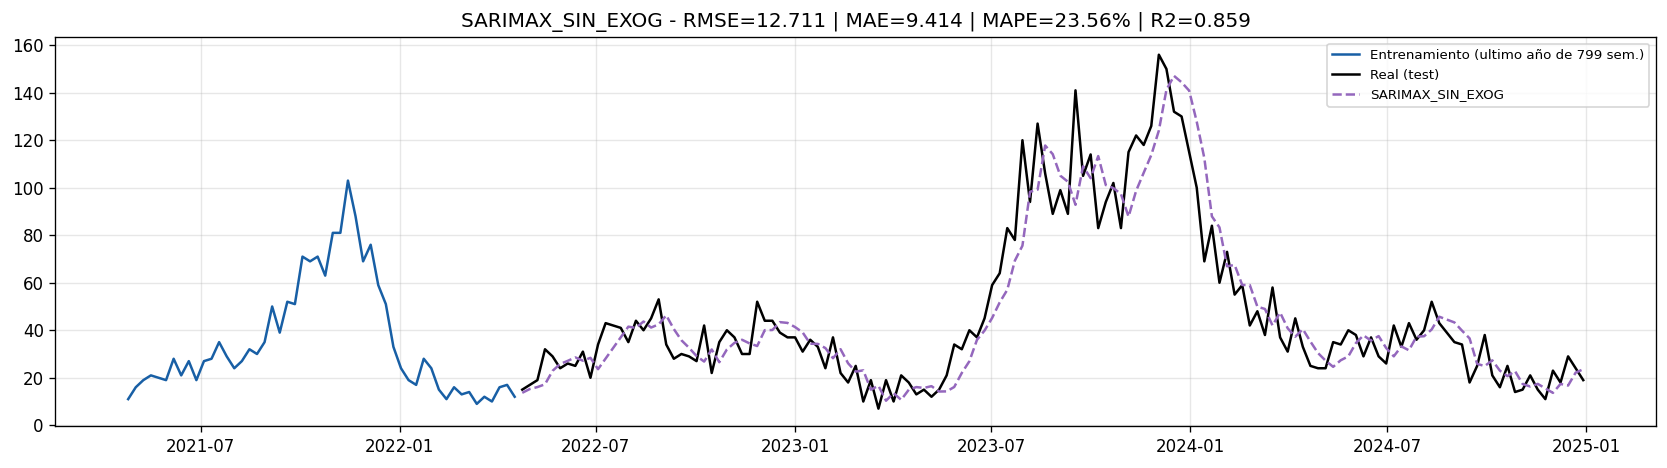

SARIMAX_SIN_EXOG                    RMSE=  12.71 | MAE=  9.41 | MAPE= 23.56% | R2=0.8590


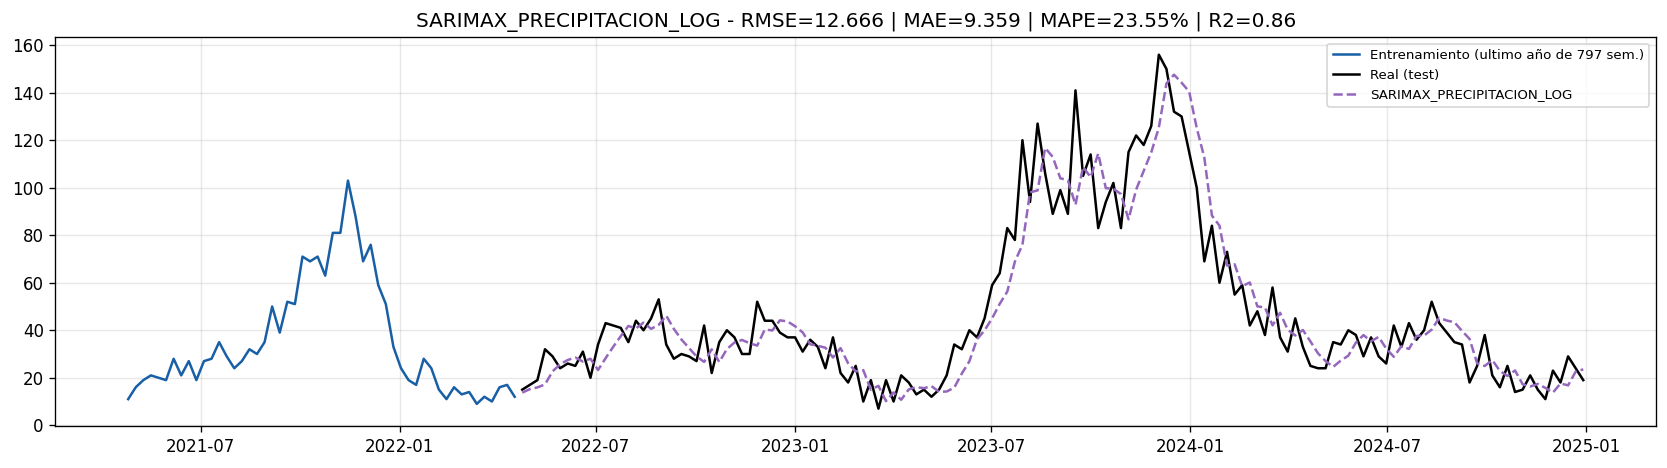

SARIMAX_PRECIPITACION_LOG           RMSE=  12.67 | MAE=  9.36 | MAPE= 23.55% | R2=0.8600


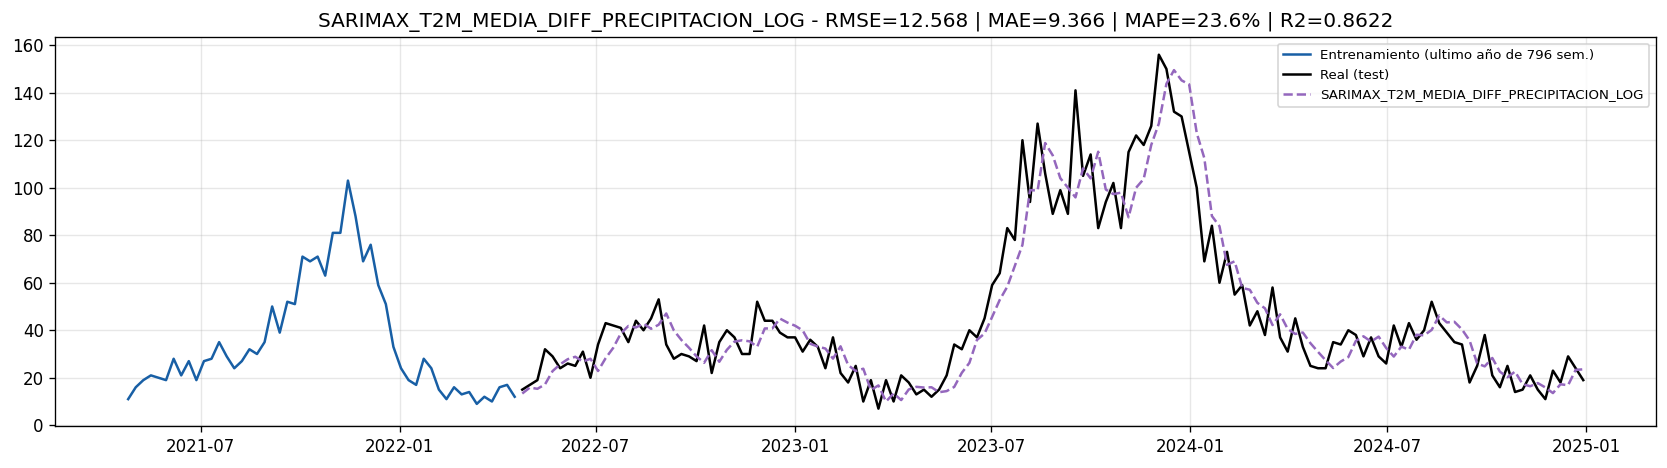

SARIMAX_T2M_MEDIA_DIFF_PRECIPITACION_LOG RMSE=  12.57 | MAE=  9.37 | MAPE= 23.60% | R2=0.8622


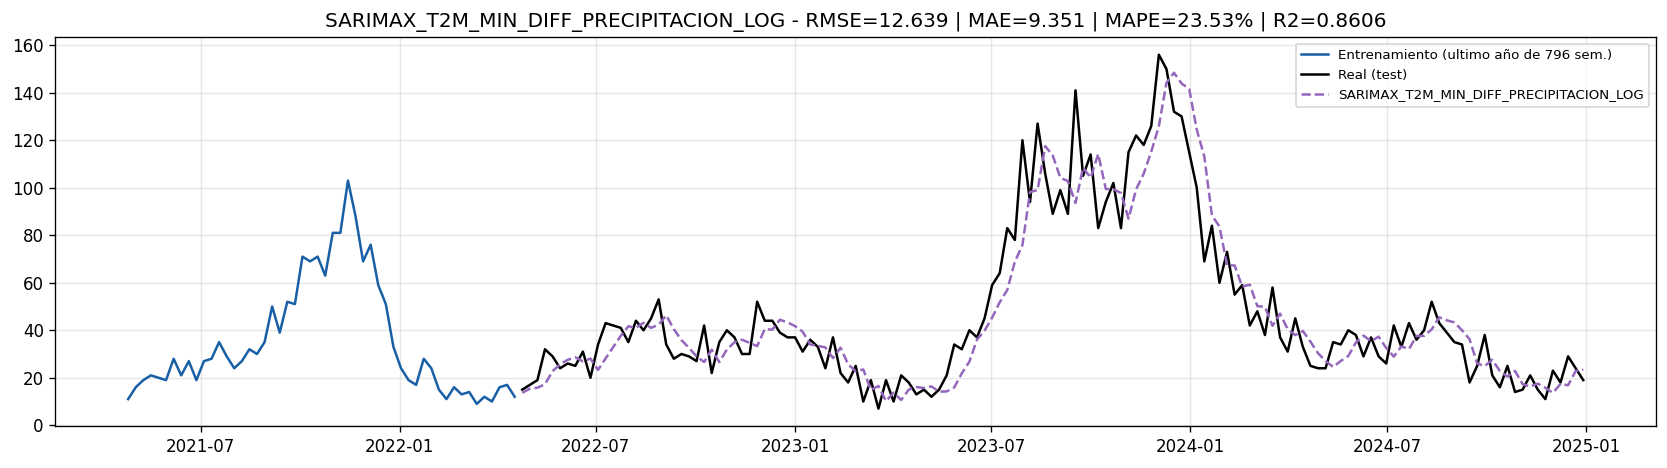

SARIMAX_T2M_MIN_DIFF_PRECIPITACION_LOG RMSE=  12.64 | MAE=  9.35 | MAPE= 23.53% | R2=0.8606


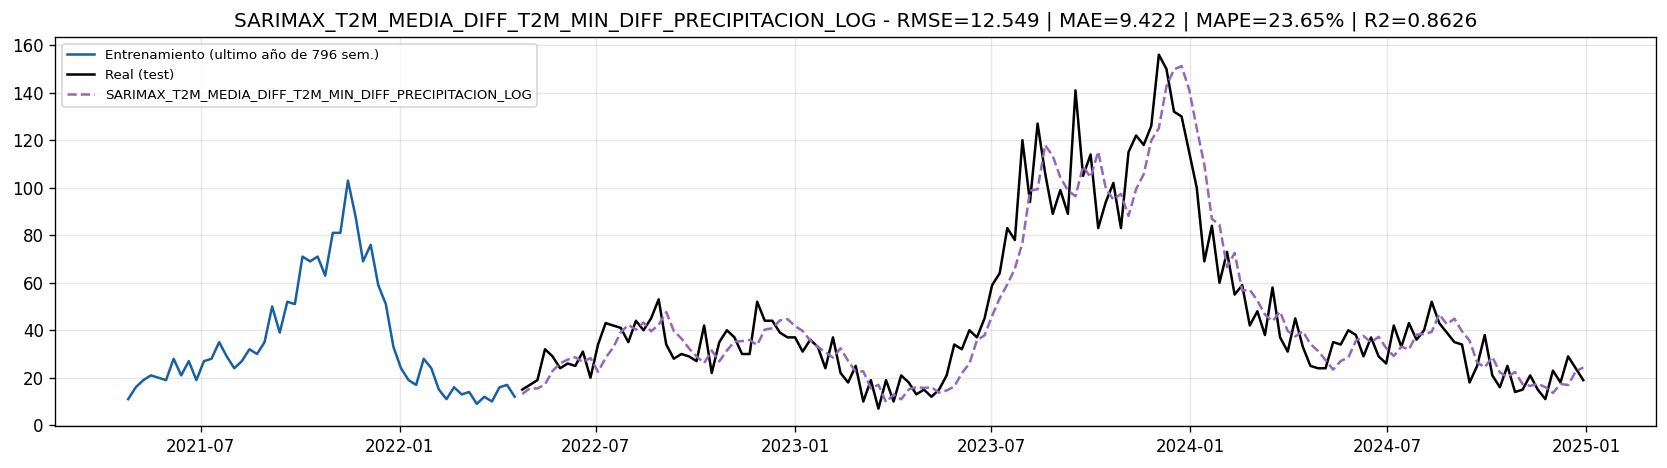

SARIMAX_T2M_MEDIA_DIFF_T2M_MIN_DIFF_PRECIPITACION_LOG RMSE=  12.55 | MAE=  9.42 | MAPE= 23.65% | R2=0.8626


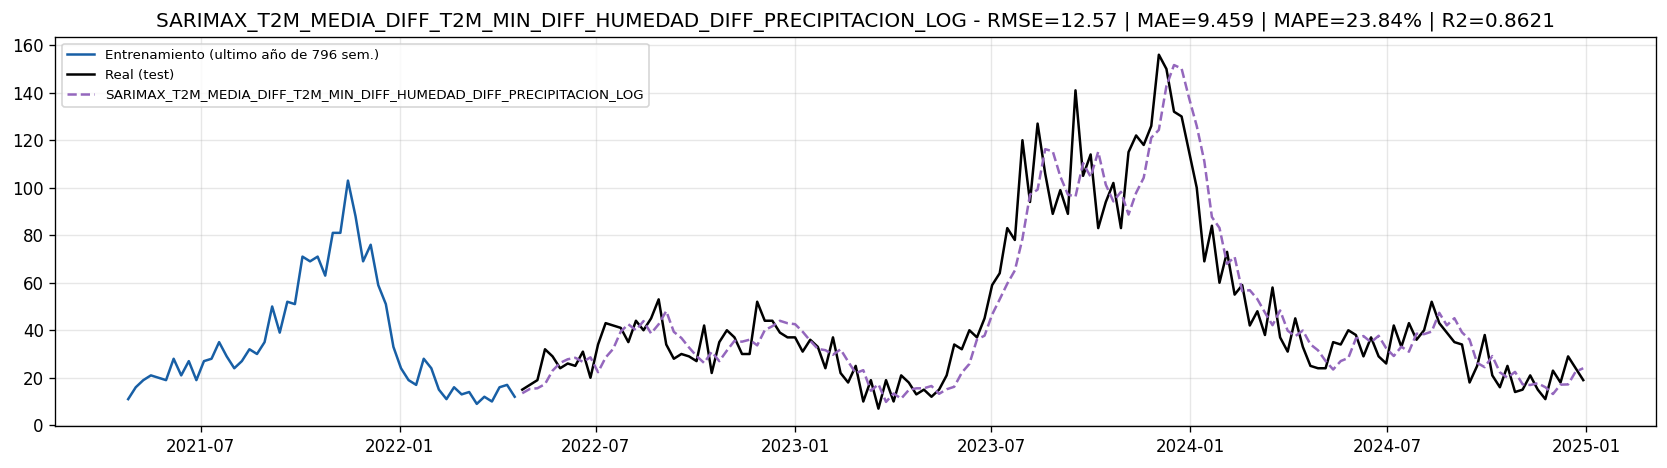

SARIMAX_T2M_MEDIA_DIFF_T2M_MIN_DIFF_HUMEDAD_DIFF_PRECIPITACION_LOG RMSE=  12.57 | MAE=  9.46 | MAPE= 23.84% | R2=0.8621

                                                                      RMSE    MAE   MAPE      R2
SARIMAX_T2M_MEDIA_DIFF_T2M_MIN_DIFF_PRECIPITACION_LOG               12.549  9.422  23.65  0.8626
SARIMAX_T2M_MEDIA_DIFF_PRECIPITACION_LOG                            12.568  9.366  23.60  0.8622
SARIMAX_T2M_MEDIA_DIFF_T2M_MIN_DIFF_HUMEDAD_DIFF_PRECIPITACION_LOG  12.570  9.459  23.84  0.8621
SARIMAX_T2M_MIN_DIFF_PRECIPITACION_LOG                              12.639  9.351  23.53  0.8606
SARIMAX_PRECIPITACION_LOG                                           12.666  9.359  23.55  0.8600
SARIMAX_SIN_EXOG                                                    12.711  9.414  23.56  0.8590


In [45]:
ORDER = (2, 1, 2)
SEASONAL_ORDER = (0, 0, 0, 52)

# Cada variable entra en la forma en que resulto estacionaria en el diagnostico:
# precipitacion como log, humedad y temperaturas diferenciadas.
combinaciones_exog = [
    [],
    ['precipitacion_log'],
    ['t2m_media_diff', 'precipitacion_log'],
    ['t2m_min_diff', 'precipitacion_log'],
    ['t2m_media_diff', 't2m_min_diff', 'precipitacion_log'],
    ['t2m_media_diff', 't2m_min_diff', 'humedad_diff', 'precipitacion_log'],
]

resultados_sarimax = {}
for exog_vars in combinaciones_exog:
    run_name, m = correr_sarimax(exog_vars, ORDER, SEASONAL_ORDER, FECHAS_TRAINVAL, FECHAS_TEST)
    resultados_sarimax[run_name] = m

print()
df_exp = pd.DataFrame(resultados_sarimax).T.sort_values('RMSE')
print(df_exp.to_string())

## 4.2 Prophet

Prophet es un modelo desarrollado por Meta para pronostico de series con estacionalidad fuerte. A diferencia de SARIMAX, descompone la serie de forma aditiva en tendencia, estacionalidad y efectos de regresores, y es mas robusto frente a datos faltantes y valores atipicos. Maneja su propia estacionalidad anual de forma interna. Se entrena en escala logaritmica de casos, igual que SARIMAX, y se le pasan las mismas variables climaticas rezagadas como regresores, para compararlo en igualdad de condiciones. Tambien entrena con train mas val y predice el test.

15:09:10 - cmdstanpy - INFO - Chain [1] start processing
15:09:10 - cmdstanpy - INFO - Chain [1] done processing


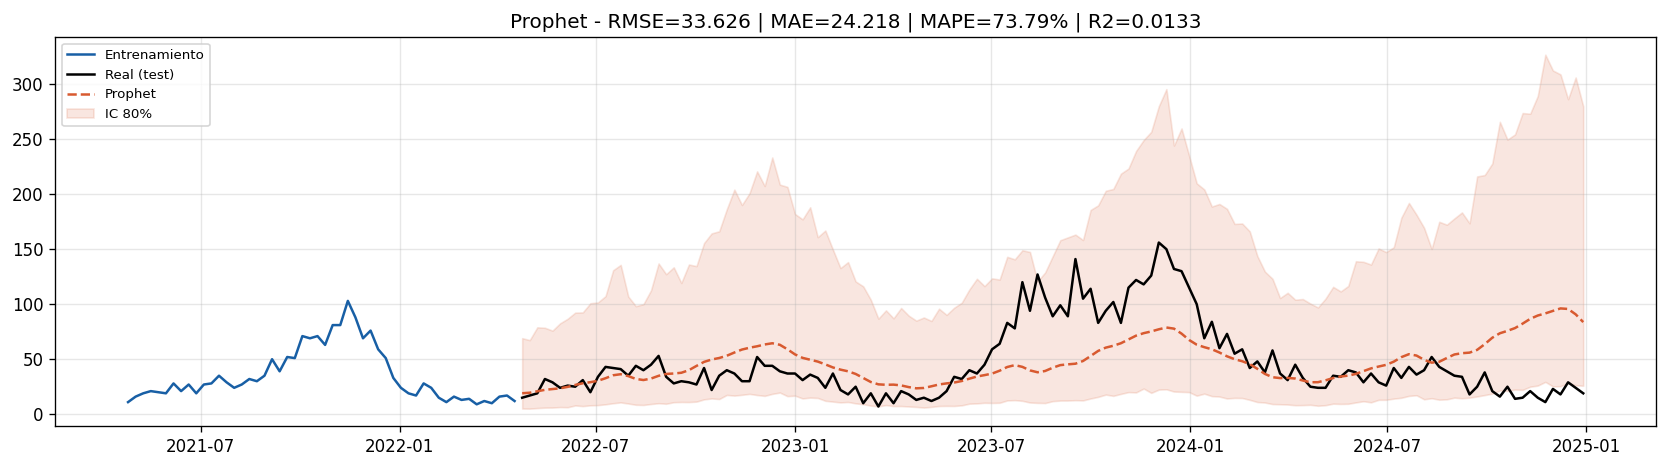

Prophet                             RMSE=  33.63 | MAE= 24.22 | MAPE= 73.79% | R2=0.0133


15:09:12 - cmdstanpy - INFO - Chain [1] start processing
15:09:12 - cmdstanpy - INFO - Chain [1] done processing


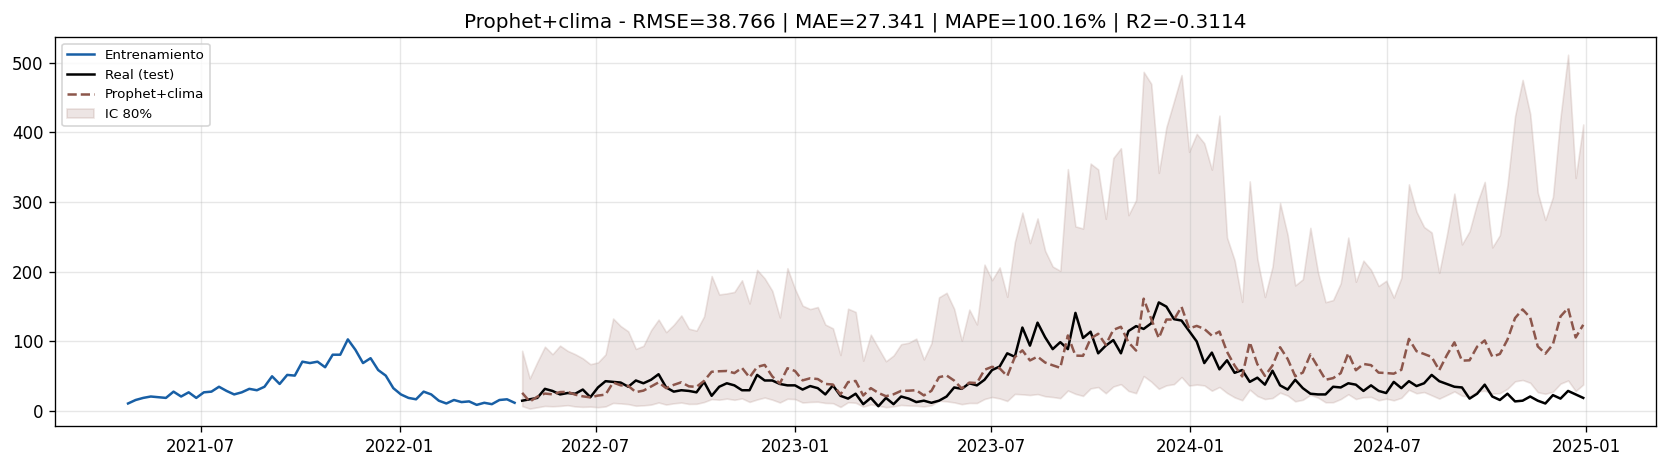

15:09:13 - cmdstanpy - INFO - Chain [1] start processing


Prophet+clima                       RMSE=  38.77 | MAE= 27.34 | MAPE=100.16% | R2=-0.3114


15:09:13 - cmdstanpy - INFO - Chain [1] done processing


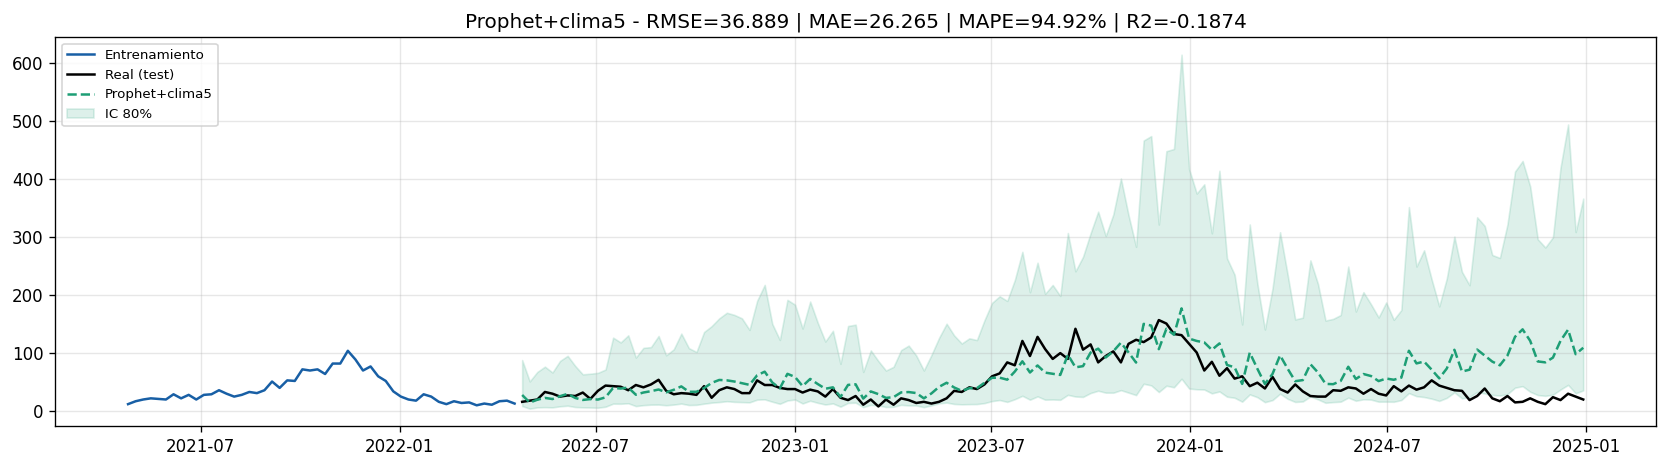

Prophet+clima5                      RMSE=  36.89 | MAE= 26.27 | MAPE= 94.92% | R2=-0.1874


In [44]:
PROPHET_EXOG_2 = ['t2m_media', 'humedad']
PROPHET_EXOG_5 = ['humedad', 'precipitacion_log', 't2m_max', 't2m_media', 't2m_min']

# Todas las variables que algun modelo Prophet podria usar, rezagadas.
TODAS_EXOG = ['humedad', 'precipitacion', 'precipitacion_log', 't2m_max', 't2m_media', 't2m_min']

base_p = df_dep.copy()
base_p['precipitacion_log'] = np.log1p(base_p['precipitacion'])
for v in TODAS_EXOG:
    base_p[f'{v}_lag{LAG_EXOG}'] = base_p[v].shift(LAG_EXOG)
base_p['casos_log'] = np.log1p(base_p['casos'])

cols_todas = [f'{v}_lag{LAG_EXOG}' for v in TODAS_EXOG]
base_p = base_p.dropna(subset=cols_todas)

entreno_p = base_p[base_p['fecha_semana'].isin(FECHAS_TRAINVAL)]
test_p = base_p[base_p['fecha_semana'].isin(FECHAS_TEST)]


def correr_prophet(exog_vars, run_name, color):
    cols = [f'{v}_lag{LAG_EXOG}' for v in exog_vars]

    df_entreno = entreno_p[['fecha_semana', 'casos_log'] + cols].rename(
        columns={'fecha_semana': 'ds', 'casos_log': 'y'})
    df_test = test_p[['fecha_semana', 'casos'] + cols].rename(
        columns={'fecha_semana': 'ds', 'casos': 'y'})

    with mlflow.start_run(run_name=run_name):
        m_obj = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        for col in cols:
            m_obj.add_regressor(col)
        m_obj.fit(df_entreno)

        forecast = m_obj.predict(df_test)
        pred = np.expm1(forecast['yhat']).clip(lower=0).values
        pred_lower = np.expm1(forecast['yhat_lower']).clip(lower=0)
        pred_upper = np.expm1(forecast['yhat_upper']).clip(lower=0)

        m = compute_metrics(df_test['y'], pred)
        mlflow.log_params({
            'yearly_seasonality': True,
            'regressors': ','.join(exog_vars) if exog_vars else 'ninguna',
            'escala_entrenamiento': 'log1p', 'entrenamiento': 'train+val',
            'escala': 'departamental',
        })
        mlflow.log_metrics(m)

        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(df_entreno['ds'].iloc[-52:], np.expm1(df_entreno['y']).iloc[-52:],
                color='#185FA5', label='Entrenamiento')
        ax.plot(df_test['ds'], df_test['y'], color='black', label='Real (test)')
        ax.plot(forecast['ds'], pred, color=color, linestyle='--', label=run_name)
        ax.fill_between(forecast['ds'], pred_lower, pred_upper, alpha=0.15, color=color, label='IC 80%')
        ax.set_title(f'{run_name} - RMSE={m["RMSE"]} | MAE={m["MAE"]} | MAPE={m["MAPE"]}% | R2={m["R2"]}')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        plt.tight_layout()
        fig_path = OUTPUTS / f'{run_name}.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        mlflow.log_artifact(str(fig_path))
        plt.show()

    print_metrics(run_name, m)
    return m


m_prophet_solo = correr_prophet([], run_name='Prophet', color='#D85A30')
m_prophet_2var = correr_prophet(PROPHET_EXOG_2, run_name='Prophet+clima', color='#8c564b')
m_prophet_5var = correr_prophet(PROPHET_EXOG_5, run_name='Prophet+clima5', color='#1D9E75')

# 5 Gradient Boosting

A diferencia de los modelos estadisticos que reciben solo la serie de casos, estos usan features construidas a partir de la serie (lags, medias moviles, codificacion de calendario). El gradient boosting construye muchos arboles de decision secuencialmente, donde cada arbol corrige los errores del anterior, lo que captura bien las relaciones no lineales entre el clima y los casos. La ingenieria de caracteristicas es especifica de esta familia: los modelos estadisticos no la usan y las redes neuronales arman sus propias secuencias, por lo que se construye aqui y no antes.

Los hiperparametros se eligen con validacion cruzada temporal (TimeSeriesSplit dentro de GridSearchCV) sobre el bloque train mas val, que respeta el orden cronologico y nunca usa semanas futuras para validar semanas pasadas. Una vez fijados, el modelo se reentrena con todo train mas val y se evalua una sola vez sobre el test. No se usa early stopping: con la busqueda en malla, el numero de arboles se trata como un hiperparametro mas y la regularizacion controla el sobreajuste.

## 5.1 Ingenieria de caracteristicas (lag features, rolling, clima)

Los modelos de arboles no entienden el tiempo por si solos: necesitan que la informacion temporal se exprese como columnas. Se generan lags climaticos (el rezago de 2 semanas refleja el periodo de incubacion extrinseco del virus en el mosquito), medias moviles climaticas, lags del target incluyendo el de 52 semanas (que captura el mismo periodo del año anterior), una codificacion ciclica de la semana epidemiologica con seno y coseno, y los lags se calculan solo con valores pasados de cada serie.

La creacion de lags antes de la division no produce fuga porque cada lag usa unicamente valores anteriores de la propia serie. Tras construir las features se asigna cada fila a train mas val o a test segun los conjuntos de fechas de la seccion 3, de modo que la particion coincida con la del resto de modelos.

In [17]:
CLIMA_VARS = ['humedad', 'precipitacion', 't2m_max', 't2m_media', 't2m_min']
LAGS_CLIMA = [1, 2, 4]
LAGS_TARGET = [1, 2, 3, 4, 52]


def build_features(serie_dep: pd.DataFrame) -> pd.DataFrame:
    out = serie_dep.copy().sort_values('fecha_semana').reset_index(drop=True)
    out['semana_epi'] = out['fecha_semana'].dt.isocalendar().week.astype(int)

    # Lags y medias moviles del clima.
    for var in CLIMA_VARS:
        for lag in LAGS_CLIMA:
            out[f'{var}_lag{lag}'] = out[var].shift(lag)
        for win in [2, 4]:
            out[f'{var}_roll{win}'] = out[var].shift(1).rolling(win, min_periods=1).mean()

    # Lags y media movil del target.
    for lag in LAGS_TARGET:
        out[f'casos_lag{lag}'] = out['casos'].shift(lag)
    out['casos_roll4'] = out['casos'].shift(1).rolling(4, min_periods=1).mean()

    # Codificacion ciclica de la semana epidemiologica.
    out['sem_sin'] = np.sin(2 * np.pi * out['semana_epi'] / 52)
    out['sem_cos'] = np.cos(2 * np.pi * out['semana_epi'] / 52)

    return out.dropna().reset_index(drop=True)


df_feat = build_features(df_dep)
print(f'Serie departamental con features: {df_feat.shape}')
print(f'Features nuevas: {len(df_feat.columns) - len(df_dep.columns)}')
df_feat.head(3)

Serie departamental con features: (888, 42)
Features nuevas: 33


,fecha_semana,anio_epi,semana_epi,casos,humedad,precipitacion,t2m_max,t2m_media,t2m_min,humedad_lag1,...,t2m_min_roll2,t2m_min_roll4,casos_lag1,casos_lag2,casos_lag3,casos_lag4,casos_lag52,casos_roll4,sem_sin,sem_cos
0,2007-12-30,2008,52,7,74.325867,0.069948,31.106298,25.927944,21.766296,85.153442,...,22.813083,22.571000,32.0,20.0,40.0,48.0,3.0,35.00,6.432491e-16,1.000000
1,2008-01-06,2008,1,12,78.003838,1.113973,30.480108,26.101784,22.554869,74.325867,...,22.497011,22.544690,7.0,32.0,20.0,40.0,8.0,24.75,1.205367e-01,0.992709
2,2008-01-13,2008,2,21,73.614159,0.297359,32.284630,26.976061,22.740347,78.003838,...,22.160583,22.486833,12.0,7.0,32.0,20.0,4.0,17.75,2.393157e-01,0.970942


In [18]:
# Asignacion de las features tabulares a train+val y test, con las fechas de la seccion 3.
df_trainval_feat = df_feat[df_feat['fecha_semana'].isin(FECHAS_TRAINVAL)].copy()
df_test_feat = df_feat[df_feat['fecha_semana'].isin(FECHAS_TEST)].copy()

# Features para los modelos de arboles: se excluyen columnas no predictoras
# y las variables climaticas crudas (ya representadas por sus lags y rolling).
FEATURE_COLS = [
    c for c in df_feat.columns
    if c not in ['fecha_semana', 'municipio', 'anio_epi', 'casos', 'semana_epi',
                 'humedad', 'precipitacion', 't2m_max', 't2m_media', 't2m_min']
]

X_trainval = df_trainval_feat[FEATURE_COLS]
y_trainval = df_trainval_feat['casos']
X_test = df_test_feat[FEATURE_COLS]
y_test = df_test_feat['casos']

print(f'Train+Val features: {X_trainval.shape} | Test features: {X_test.shape}')
print(f'Total features: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Train+Val features: (747, 33) | Test features: (141, 33)
Total features: 33
['humedad_lag1', 'humedad_lag2', 'humedad_lag4', 'humedad_roll2', 'humedad_roll4', 'precipitacion_lag1', 'precipitacion_lag2', 'precipitacion_lag4', 'precipitacion_roll2', 'precipitacion_roll4', 't2m_max_lag1', 't2m_max_lag2', 't2m_max_lag4', 't2m_max_roll2', 't2m_max_roll4', 't2m_media_lag1', 't2m_media_lag2', 't2m_media_lag4', 't2m_media_roll2', 't2m_media_roll4', 't2m_min_lag1', 't2m_min_lag2', 't2m_min_lag4', 't2m_min_roll2', 't2m_min_roll4', 'casos_lag1', 'casos_lag2', 'casos_lag3', 'casos_lag4', 'casos_lag52', 'casos_roll4', 'sem_sin', 'sem_cos']


### Validacion cruzada temporal para hiperparametros

Se define una funcion reutilizable que ejecuta GridSearchCV con TimeSeriesSplit sobre train mas val. TimeSeriesSplit genera cortes crecientes en el tiempo (cada fold entrena con el pasado y valida con el bloque siguiente), por lo que nunca usa el futuro para validar. La metrica de seleccion es el RMSE negativo. La funcion devuelve el mejor estimador ya reentrenado sobre todo train mas val (refit automatico de GridSearchCV) y registra los mejores hiperparametros y el RMSE de validacion cruzada en MLflow.

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

N_SPLITS_CV = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS_CV)
rmse_scorer = make_scorer(
    lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)),
    greater_is_better=False,
)


def buscar_hiperparametros(estimador, param_grid, X, y):
    grid = GridSearchCV(
        estimator=estimador,
        param_grid=param_grid,
        scoring=rmse_scorer,
        cv=tscv,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X, y)
    rmse_cv = -grid.best_score_
    return grid.best_estimator_, grid.best_params_, rmse_cv

## 5.2 XGBoost

XGBoost es una implementacion de gradient boosting reconocida por su desempeño en datos tabulares. Construye los arboles optimizando una funcion de perdida con regularizacion, lo que ayuda a controlar el sobreajuste. Sus hiperparametros se eligen con la validacion cruzada temporal definida arriba; el mejor modelo, ya reentrenado sobre train mas val, se evalua sobre el test.

2026/06/22 12:32:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Mejores hiperparametros XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 0.8}
RMSE validacion cruzada: 16.402


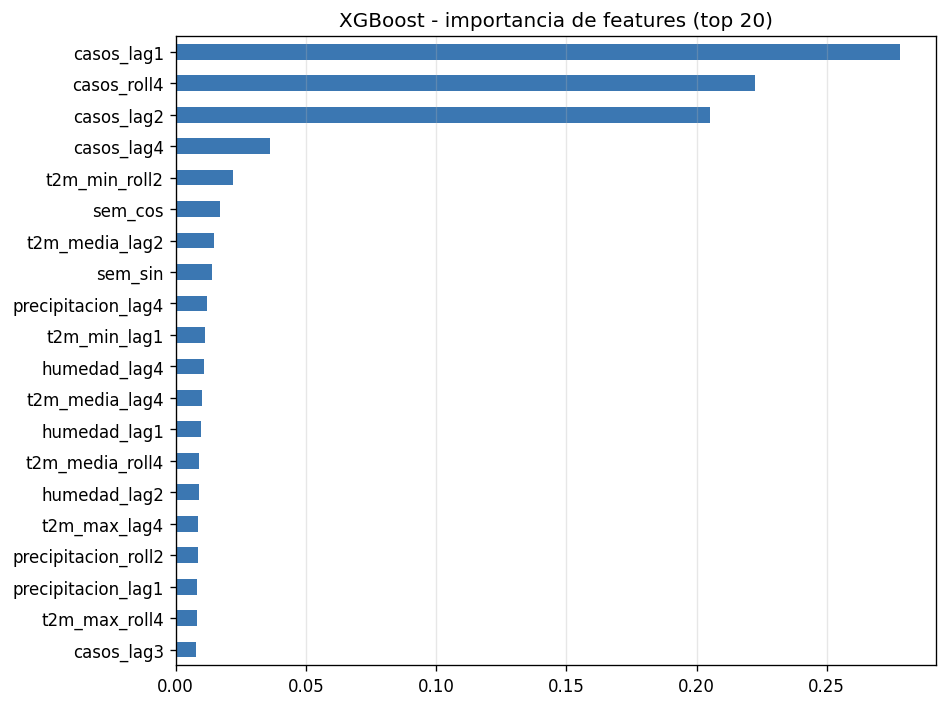

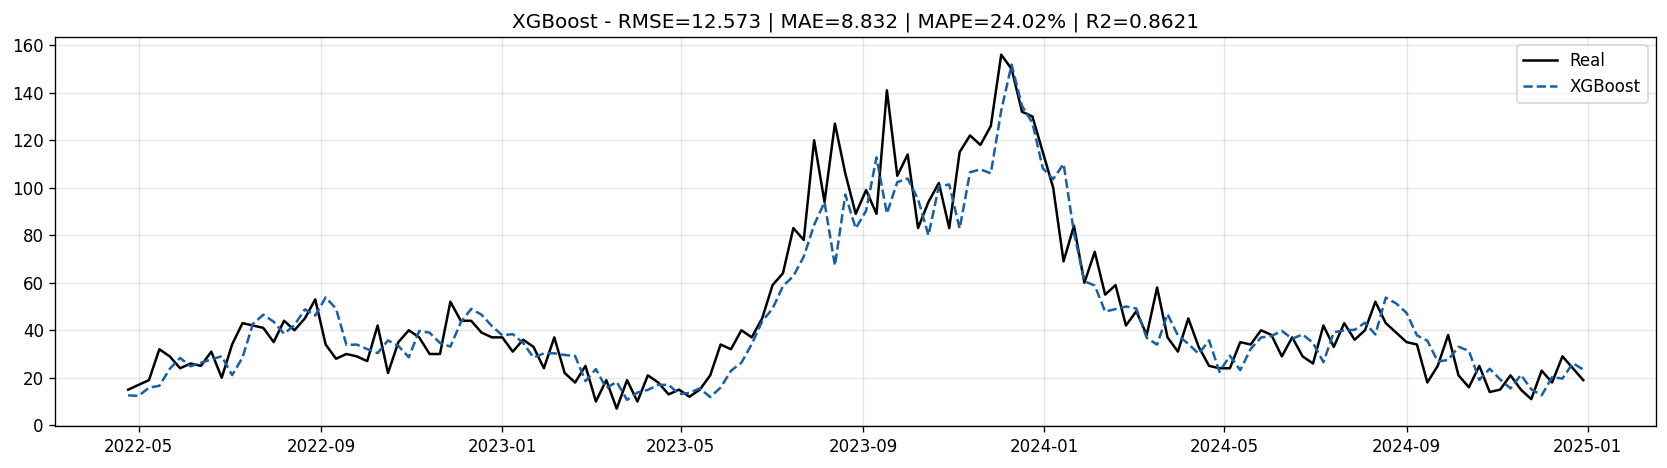

XGBoost-departamental               RMSE=  12.57 | MAE=  8.83 | MAPE= 24.02% | R2=0.8621


In [20]:
XGB_PARAM_GRID = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.03, 0.05, 0.1],
    'n_estimators': [300, 500],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'min_child_weight': [3],
}

with mlflow.start_run(run_name='XGBoost-departamental'):
    xgb_base = XGBRegressor(random_state=42, n_jobs=-1)
    xgb, best_params_xgb, rmse_cv_xgb = buscar_hiperparametros(
        xgb_base, XGB_PARAM_GRID, X_trainval, y_trainval)

    pred_xgb = xgb.predict(X_test).clip(min=0)
    m_xgb = compute_metrics(y_test, pred_xgb)

    mlflow.log_params({**best_params_xgb, 'escala': 'departamental',
                       'seleccion': 'GridSearchCV+TimeSeriesSplit', 'cv_splits': N_SPLITS_CV})
    mlflow.log_metric('rmse_cv', round(rmse_cv_xgb, 3))
    mlflow.log_metrics(m_xgb)
    mlflow.xgboost.log_model(xgb, artifact_path='model')
    print(f'Mejores hiperparametros XGBoost: {best_params_xgb}')
    print(f'RMSE validacion cruzada: {rmse_cv_xgb:.3f}')

    feat_imp_xgb = pd.Series(xgb.feature_importances_, index=FEATURE_COLS).nlargest(20)
    fig, ax = plt.subplots(figsize=(8, 6))
    feat_imp_xgb.sort_values().plot(kind='barh', ax=ax, color='#185FA5', alpha=0.85)
    ax.set_title('XGBoost - importancia de features (top 20)')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    imp_path = OUTPUTS / 'xgb_feature_importance.png'
    plt.savefig(imp_path, dpi=150, bbox_inches='tight')
    mlflow.log_artifact(str(imp_path))
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df_test_feat['fecha_semana'], y_test.values, color='black', label='Real')
    ax.plot(df_test_feat['fecha_semana'], pred_xgb, color='#185FA5', linestyle='--', label='XGBoost')
    ax.set_title(f'XGBoost - RMSE={m_xgb["RMSE"]} | MAE={m_xgb["MAE"]} | MAPE={m_xgb["MAPE"]}% | R2={m_xgb["R2"]}')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    fig_path = OUTPUTS / 'xgb_pred.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    mlflow.log_artifact(str(fig_path))
    plt.show()

print_metrics('XGBoost-departamental', m_xgb)

## 5.3 LightGBM

LightGBM es otra implementacion de gradient boosting, optimizada para ser mas rapida y eficiente en memoria que XGBoost, con desempeño comparable. Crece los arboles por hojas (leaf-wise) en lugar de por niveles. Sigue el mismo procedimiento de seleccion por validacion cruzada temporal. Se usa ademas como modelo base para el analisis de interpretabilidad SHAP de la seccion 8.

2026/06/22 12:33:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 12:33:53 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Mejores hiperparametros LightGBM: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 15, 'subsample': 0.8}
RMSE validacion cruzada: 16.229


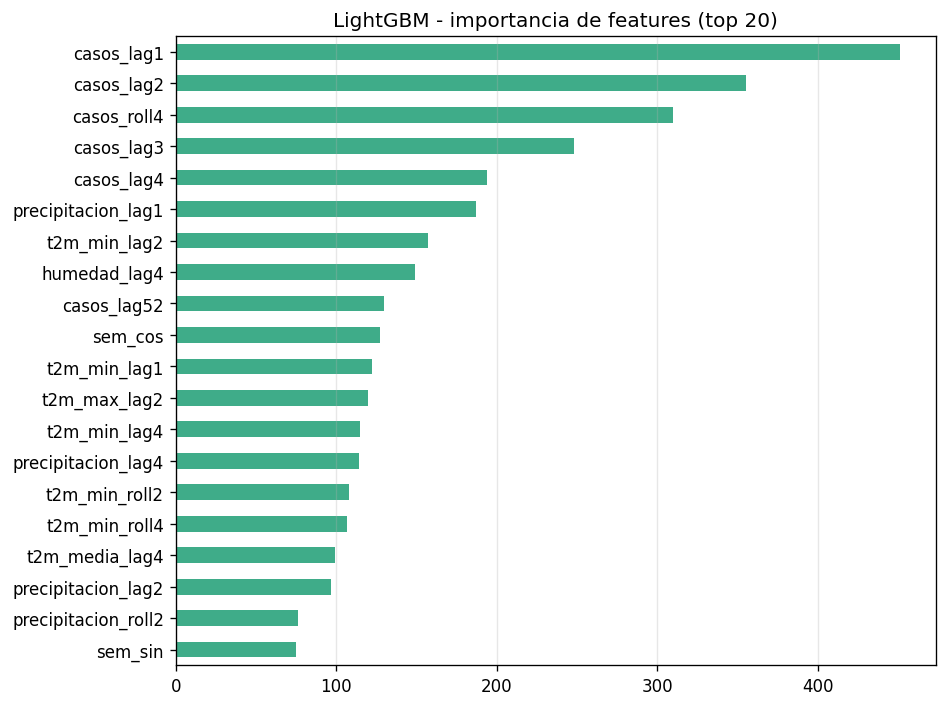

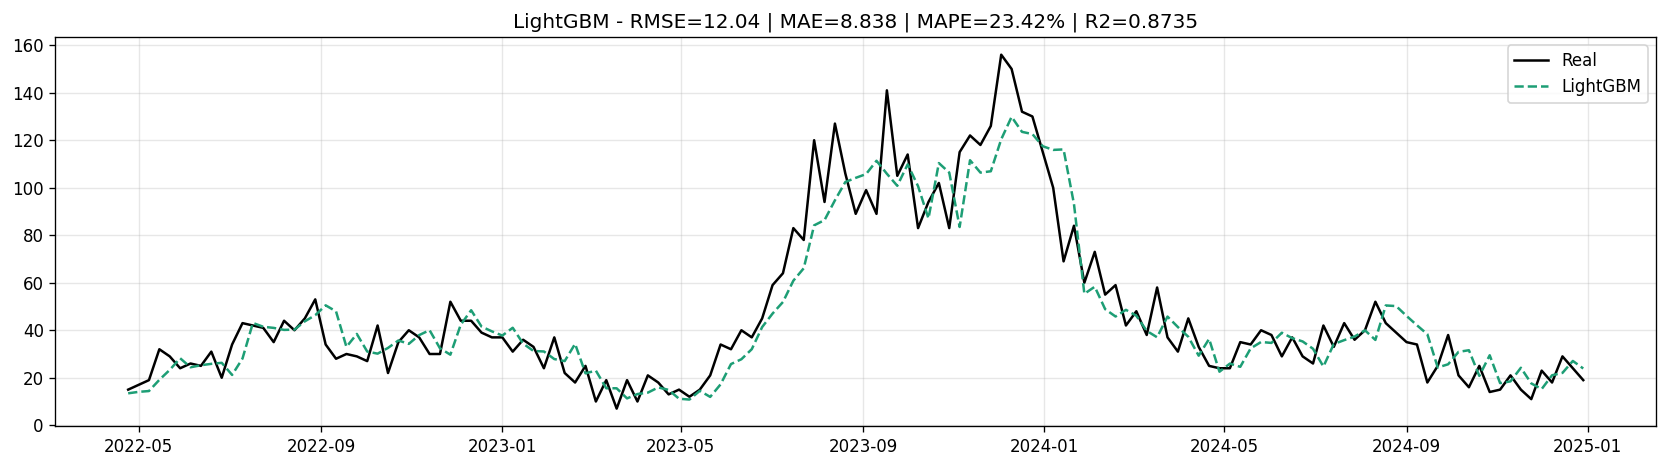

LightGBM-departamental              RMSE=  12.04 | MAE=  8.84 | MAPE= 23.42% | R2=0.8735


In [21]:
LGBM_PARAM_GRID = {
    'num_leaves': [15, 31, 63],
    'learning_rate': [0.03, 0.05, 0.1],
    'n_estimators': [300, 500],
    'min_child_samples': [20],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}

with mlflow.start_run(run_name='LightGBM-departamental'):
    lgbm_base = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
    lgbm, best_params_lgbm, rmse_cv_lgbm = buscar_hiperparametros(
        lgbm_base, LGBM_PARAM_GRID, X_trainval, y_trainval)

    pred_lgbm = lgbm.predict(X_test).clip(min=0)
    m_lgbm = compute_metrics(y_test, pred_lgbm)

    mlflow.log_params({**best_params_lgbm, 'escala': 'departamental',
                       'seleccion': 'GridSearchCV+TimeSeriesSplit', 'cv_splits': N_SPLITS_CV})
    mlflow.log_metric('rmse_cv', round(rmse_cv_lgbm, 3))
    mlflow.log_metrics(m_lgbm)
    mlflow.lightgbm.log_model(lgbm, artifact_path='model')
    print(f'Mejores hiperparametros LightGBM: {best_params_lgbm}')
    print(f'RMSE validacion cruzada: {rmse_cv_lgbm:.3f}')

    feat_imp_lgbm = pd.Series(lgbm.feature_importances_, index=FEATURE_COLS).nlargest(20)
    fig, ax = plt.subplots(figsize=(8, 6))
    feat_imp_lgbm.sort_values().plot(kind='barh', ax=ax, color='#1D9E75', alpha=0.85)
    ax.set_title('LightGBM - importancia de features (top 20)')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    imp_path = OUTPUTS / 'lgbm_feature_importance.png'
    plt.savefig(imp_path, dpi=150, bbox_inches='tight')
    mlflow.log_artifact(str(imp_path))
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df_test_feat['fecha_semana'], y_test.values, color='black', label='Real')
    ax.plot(df_test_feat['fecha_semana'], pred_lgbm, color='#1D9E75', linestyle='--', label='LightGBM')
    ax.set_title(f'LightGBM - RMSE={m_lgbm["RMSE"]} | MAE={m_lgbm["MAE"]} | MAPE={m_lgbm["MAPE"]}% | R2={m_lgbm["R2"]}')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    fig_path = OUTPUTS / 'lgbm_pred.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    mlflow.log_artifact(str(fig_path))
    plt.show()

print_metrics('LightGBM-departamental', m_lgbm)

# 6 Deep Learning

Esta seccion agrupa los modelos de redes neuronales. A diferencia de los modelos de arboles, que requieren features construidas a mano, las redes aprenden la estructura temporal directamente de ventanas de semanas consecutivas. Ambos modelos de esta seccion (LSTM y N-BEATS) reservan un bloque de validacion interno, recortado del final de train mas val mediante FECHAS_VAL, que se usa solo para early stopping. El test es el mismo 15 por ciento final que el de los demas modelos.

## 6.1 LSTM - preparacion de secuencias

Las redes LSTM (Long Short-Term Memory) son un tipo de red neuronal recurrente diseñada para aprender dependencias temporales largas. La red recibe una ventana de semanas consecutivas y aprende sola que informacion del pasado es relevante. La ventana de entrada es de 12 semanas.

El orden de preprocesamiento es importante y sigue la secuencia correcta: primero se transforma la serie de casos con log1p para estabilizar la varianza, luego se ajusta el MinMaxScaler solo con los datos de entrenamiento (hasta el inicio de la validacion interna) para no filtrar informacion futura, y por ultimo se construyen las secuencias deslizantes. En la inversion se aplica primero el inverse_transform del scaler y despues expm1, revirtiendo las dos transformaciones en el orden inverso al que se aplicaron. El corte de validacion interno se obtiene de FECHAS_VAL y solo se usa para el early stopping.

In [22]:
LSTM_FEATURES = ['casos', 't2m_media', 'precipitacion', 'humedad']
WINDOW = 12

# Indexado por fecha y ordenado cronologicamente sobre todo el periodo.
df_lstm_raw = df_dep.set_index('fecha_semana')[LSTM_FEATURES].copy()

# log1p sobre casos ANTES de escalar (la varianza de casos crece con el nivel).
# El resto de variables climaticas no necesita log1p (ver seccion 2 y 4.1).
df_lstm_log = df_lstm_raw.copy()
df_lstm_log['casos'] = np.log1p(df_lstm_log['casos'])

# Limites de posicion alineados a las fechas de la seccion 3.
# train interno = train (70%), val interno = val (15%), test = test (15%).
fechas_orden = df_lstm_log.index
pos_val = fechas_orden.isin(FECHAS_TRAIN).sum()            # fin de train, inicio de val
pos_test = pos_val + fechas_orden.isin(FECHAS_VAL).sum()   # fin de val, inicio de test

# Scaler ajustado SOLO con el train interno (en escala log para casos).
scaler = MinMaxScaler()
scaler.fit(df_lstm_log.iloc[:pos_val][LSTM_FEATURES])
scaled = scaler.transform(df_lstm_log[LSTM_FEATURES])
df_scaled = pd.DataFrame(scaled, index=df_lstm_log.index, columns=LSTM_FEATURES)


def make_sequences(df_s, window=WINDOW):
    arr = df_s[LSTM_FEATURES].values
    X, y = [], []
    for i in range(window, len(arr)):
        X.append(arr[i - window:i])
        y.append(arr[i, 0])
    return np.array(X), np.array(y)


X_all, y_all = make_sequences(df_scaled)

X_tr = X_all[:pos_val - WINDOW]
y_tr = y_all[:pos_val - WINDOW]
X_va = X_all[pos_val - WINDOW:pos_test - WINDOW]
y_va = y_all[pos_val - WINDOW:pos_test - WINDOW]
X_te = X_all[pos_test - WINDOW:]
y_te = y_all[pos_test - WINDOW:]

print(f'Train: {X_tr.shape} | Val (early stopping): {X_va.shape} | Test: {X_te.shape}')

Train: (646, 12, 4) | Val (early stopping): (141, 12, 4) | Test: (141, 12, 4)


## 6.2 LSTM - arquitectura y entrenamiento

Se define una red de dos capas LSTM apiladas con dropout para regularizar, seguida de capas densas. Se entrena con early stopping sobre la perdida de validacion para detener el entrenamiento cuando deja de mejorar. La prediccion se reconstruye a escala de casos invirtiendo el escalado y luego la transformacion logaritmica, en ese orden.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0890 - val_loss: 0.0190 - learning_rate: 0.0010
Epoch 2/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0231 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 3/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0180 - val_loss: 0.0074 - learning_rate: 0.0010
Epoch 4/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0168 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 5/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0158 - val_loss: 0.0072 - learning_rate: 0.0010
Epoch 6/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0145 - val_loss: 0.0066 - learning_rate: 0.0010
Epoch 7/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0143 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 8/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0138 - val_loss: 0.0073 - learning_rate: 0.0010
Epoch 9/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0129 - val_loss: 0.0057 - learning_rate: 0.0010
Epoch 10/200


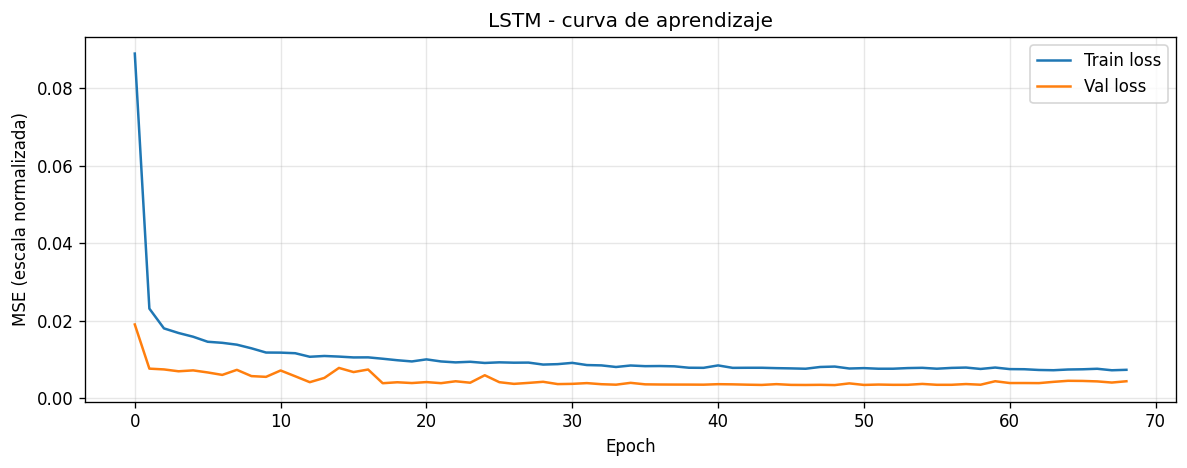

In [23]:
model_lstm = Sequential([
    LSTM(64, input_shape=(WINDOW, len(LSTM_FEATURES)), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1),
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5),
]
history = model_lstm.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=200, batch_size=16,
    callbacks=callbacks, verbose=1,
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], label='Train loss')
ax.plot(history.history['val_loss'], label='Val loss')
ax.set_title('LSTM - curva de aprendizaje')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (escala normalizada)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


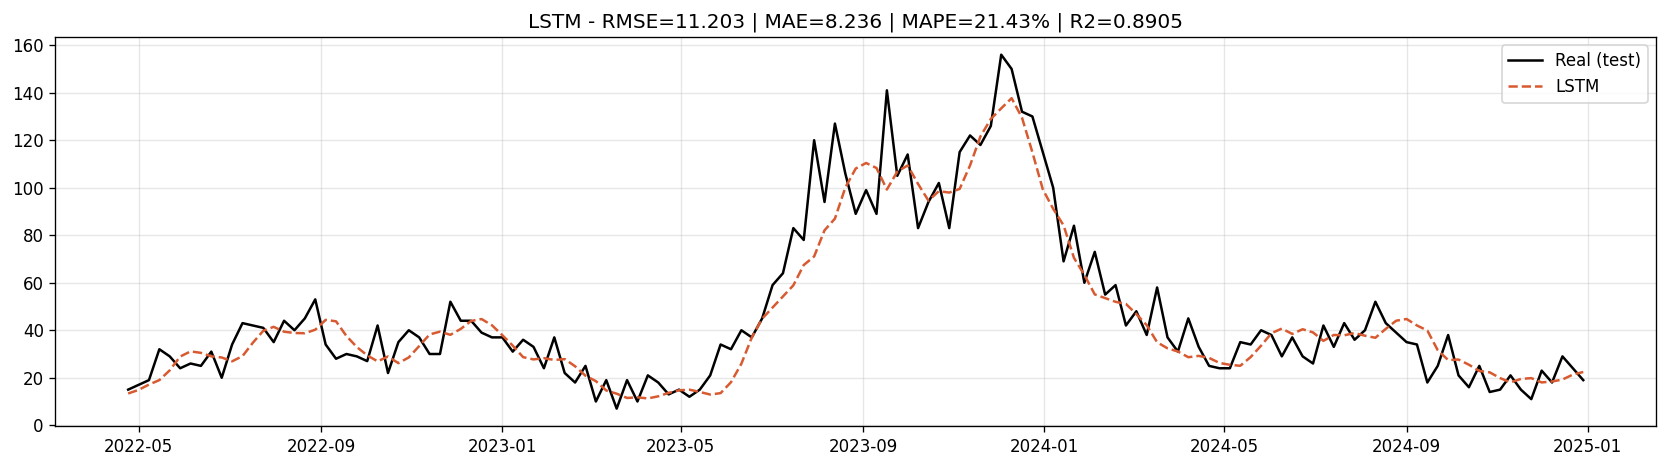

LSTM                                RMSE=  11.20 | MAE=  8.24 | MAPE= 21.43% | R2=0.8905


In [24]:
def inverse_casos(arr_scaled):
    # Invierte el escalado y luego la transformacion log1p, en orden inverso.
    dummy = np.zeros((len(arr_scaled), len(LSTM_FEATURES)))
    dummy[:, 0] = arr_scaled
    casos_log = scaler.inverse_transform(dummy)[:, 0]
    return np.expm1(casos_log).clip(min=0)


with mlflow.start_run(run_name='LSTM'):
    pred_lstm_scaled = model_lstm.predict(X_te).flatten()
    pred_lstm = inverse_casos(pred_lstm_scaled)
    real_lstm = inverse_casos(y_te)

    m_lstm = compute_metrics(real_lstm, pred_lstm)

    mlflow.log_params({
        'window': WINDOW, 'lstm_units_1': 64, 'lstm_units_2': 32,
        'dropout': 0.2, 'batch_size': 16, 'features': str(LSTM_FEATURES),
        'preproc': 'log1p->minmax', 'escala': 'departamental',
    })
    mlflow.log_metrics(m_lstm)
    mlflow.log_metric('epochs_trained', len(history.history['loss']))

    fechas_test_lstm = df_scaled.index[pos_test:]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(fechas_test_lstm[:len(real_lstm)], real_lstm, color='black', label='Real (test)')
    ax.plot(fechas_test_lstm[:len(pred_lstm)], pred_lstm, color='#D85A30', linestyle='--', label='LSTM')
    ax.set_title(f'LSTM - RMSE={m_lstm["RMSE"]} | MAE={m_lstm["MAE"]} | MAPE={m_lstm["MAPE"]}% | R2={m_lstm["R2"]}')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    fig_path = OUTPUTS / 'lstm_pred.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    mlflow.log_artifact(str(fig_path))
    plt.show()

print_metrics('LSTM', m_lstm)

## 6.3 N-BEATS

N-BEATS (Neural Basis Expansion Analysis for Time Series) es una arquitectura de deep learning especifica para pronostico de series, basada en bloques apilados de capas densas que producen un componente de reconstruccion del pasado (backcast) y uno de pronostico (forecast). No es recurrente como LSTM; aprende expansiones de base que descomponen la señal, lo que suele dar buen desempeño en series univariadas con estacionalidad. Se implementa con la libreria darts, que ofrece N-BEATS listo y maneja internamente el escalado y el formato de ventana.

Se entrena sobre la serie de casos en escala logaritmica de train mas val y se reserva el bloque de validacion interno (FECHAS_VAL) para el early stopping, igual que LSTM. La prediccion se revierte con expm1 antes de calcular las metricas sobre el test, que sigue siendo el mismo 15 por ciento final.

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


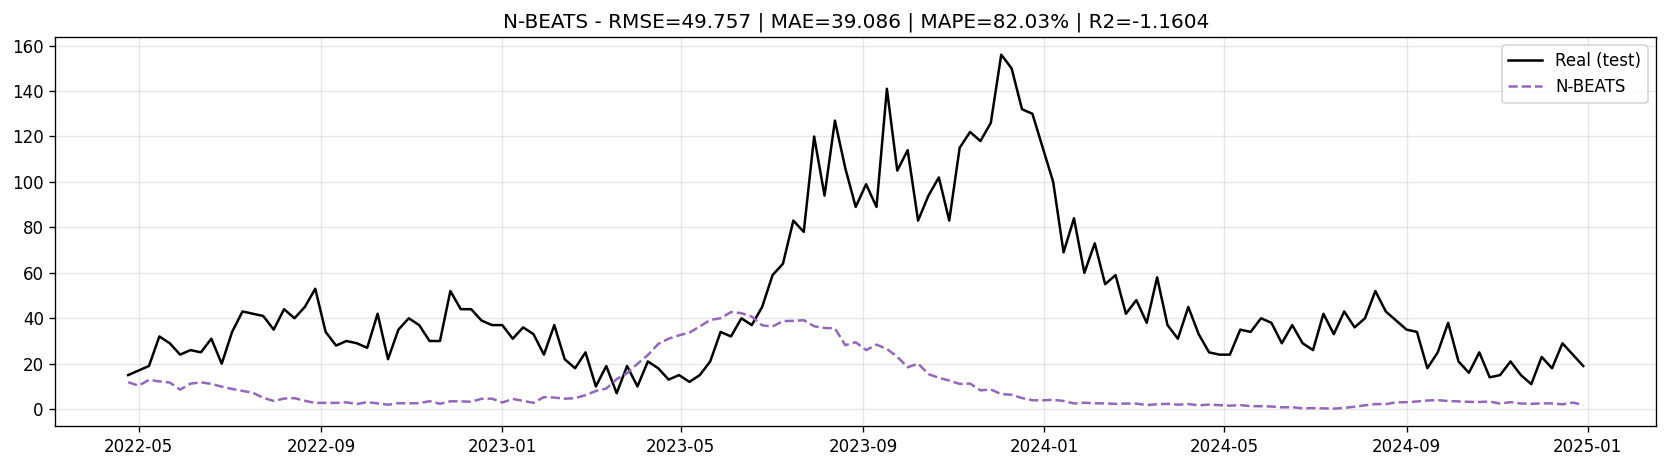

N-BEATS                             RMSE=  49.76 | MAE= 39.09 | MAPE= 82.03% | R2=-1.1604


In [25]:
# Serie univariada de casos en escala log1p, frecuencia semanal.
serie_casos_log = np.log1p(df_dep.set_index('fecha_semana')['casos'])
ts_full = TimeSeries.from_series(serie_casos_log, freq='W-SUN')

# Cortes por posicion, alineados con los conjuntos de fechas de la seccion 3.
fechas_orden_nb = df_dep.sort_values('fecha_semana')['fecha_semana']
n_train = fechas_orden_nb.isin(FECHAS_TRAIN).sum()
n_val = fechas_orden_nb.isin(FECHAS_VAL).sum()

ts_train = ts_full[:n_train]
ts_val = ts_full[n_train:n_train + n_val]
ts_test = ts_full[n_train + n_val:]

WINDOW_NB = 12
HORIZON_NB = 1

with mlflow.start_run(run_name='N-BEATS'):
    model_nbeats = NBEATSModel(
        input_chunk_length=WINDOW_NB,
        output_chunk_length=HORIZON_NB,
        n_epochs=200,
        batch_size=16,
        random_state=42,
        pl_trainer_kwargs={'enable_progress_bar': False},
    )
    model_nbeats.fit(ts_train, val_series=ts_val, verbose=False)

    # Pronostico sobre el tramo de test, anclado al final de train+val.
    ts_entreno = ts_full[:n_train + n_val]
    pred_ts = model_nbeats.predict(n=len(ts_test), series=ts_entreno)

    pred_nbeats = np.expm1(pred_ts.values().flatten()).clip(min=0)
    real_nbeats = np.expm1(ts_test.values().flatten()).clip(min=0)

    m_nbeats = compute_metrics(real_nbeats, pred_nbeats)
    mlflow.log_params({
        'input_chunk_length': WINDOW_NB, 'output_chunk_length': HORIZON_NB,
        'n_epochs': 200, 'batch_size': 16, 'escala_entrenamiento': 'log1p',
        'lib': 'darts', 'escala': 'departamental',
    })
    mlflow.log_metrics(m_nbeats)

    fechas_test_nb = fechas_orden_nb[n_train + n_val:].values
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(fechas_test_nb[:len(real_nbeats)], real_nbeats, color='black', label='Real (test)')
    ax.plot(fechas_test_nb[:len(pred_nbeats)], pred_nbeats, color='#9467bd', linestyle='--', label='N-BEATS')
    ax.set_title(f'N-BEATS - RMSE={m_nbeats["RMSE"]} | MAE={m_nbeats["MAE"]} | MAPE={m_nbeats["MAPE"]}% | R2={m_nbeats["R2"]}')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    fig_path = OUTPUTS / 'nbeats_pred.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    mlflow.log_artifact(str(fig_path))
    plt.show()

print_metrics('N-BEATS', m_nbeats)

# 7 Comparacion de modelos

Todos los modelos operan sobre la serie departamental y se evaluan sobre las mismas semanas de prueba (el 15 por ciento mas reciente de la particion de la seccion 3) con las mismas metricas, por lo que la comparacion es directa y justa. Las corridas quedan registradas en MLflow bajo el experimento dengue-magdalena.

TODO: tras ejecutar, redactar la conclusion del modelo ganador y su justificacion.

Limitacion conocida: este notebook pronostica unicamente a nivel departamental. El pronostico por municipio requiere un enfoque distinto (modelos de panel o un esquema hibrido para manejar la alta proporcion de semanas con cero casos), pendiente de definir.

                                                    Modelo           Familia        Escala   RMSE    MAE   MAPE      R2
                                                      LSTM     Deep Learning Departamental 11.203  8.236  21.43  0.8905
                                                  LightGBM Gradient Boosting Departamental 12.040  8.838  23.42  0.8735
                                                   XGBoost Gradient Boosting Departamental 12.573  8.832  24.02  0.8621
                                           Prophet + clima       Estadistico Departamental 41.158 29.062 110.40 -0.4782
SARIMAX (SARIMAX_T2M_MEDIA_DIFF_T2M_MIN_DIFF_T2M_MAX_DIFF)       Estadistico Departamental 46.938 32.852  56.63 -0.9226
                                                   N-BEATS     Deep Learning Departamental 49.757 39.086  82.03 -1.1604


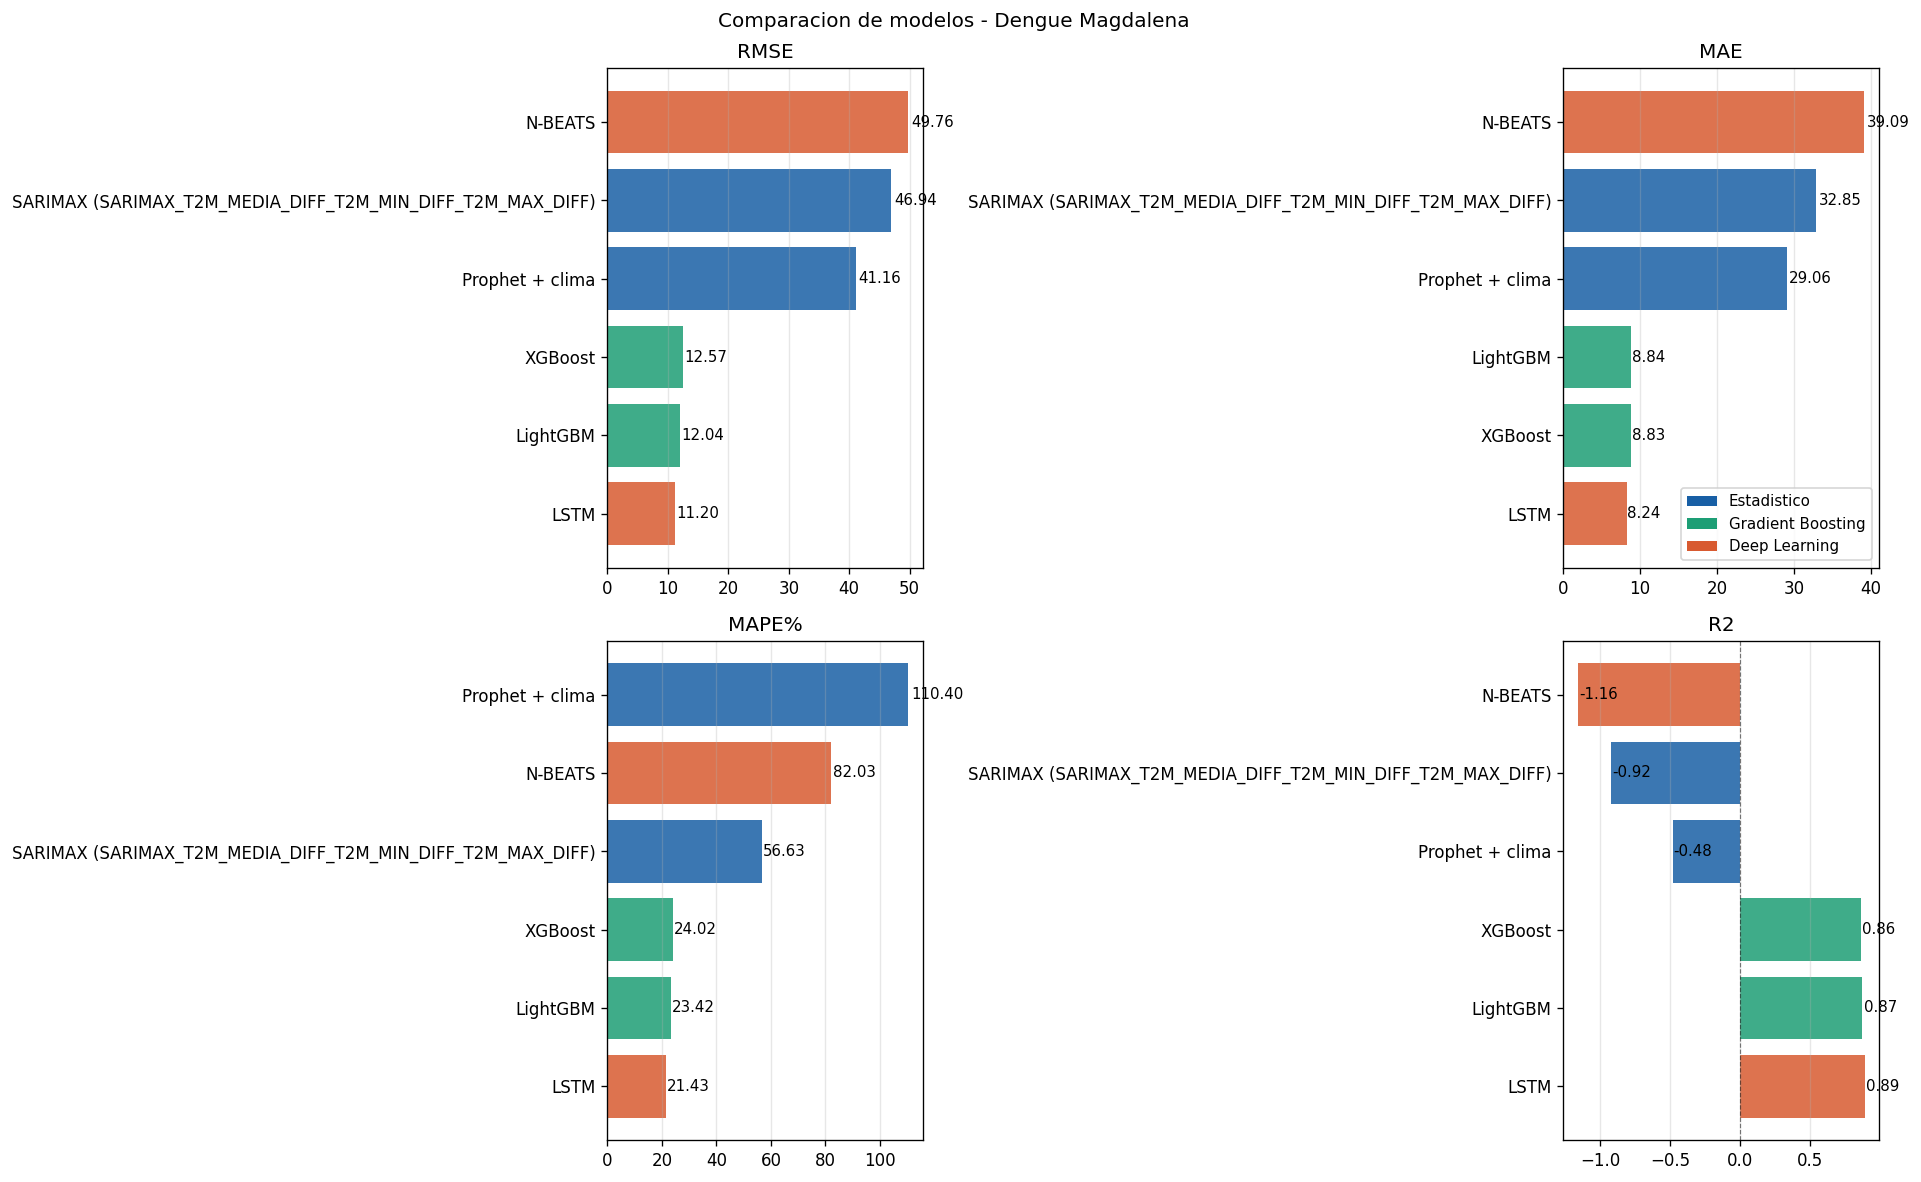

In [26]:
from matplotlib.patches import Patch

mejor_nombre_sarimax = min(resultados_sarimax, key=lambda k: resultados_sarimax[k]['RMSE'])
m_sarimax = resultados_sarimax[mejor_nombre_sarimax]

metricas_modelos = [
    (f'SARIMAX ({mejor_nombre_sarimax})', 'Estadistico',       'Departamental', m_sarimax),
    ('Prophet + clima',                   'Estadistico',       'Departamental', m_prophet_2var),
    ('XGBoost',                           'Gradient Boosting', 'Departamental', m_xgb),
    ('LightGBM',                          'Gradient Boosting', 'Departamental', m_lgbm),
    ('LSTM',                              'Deep Learning',     'Departamental', m_lstm),
    ('N-BEATS',                           'Deep Learning',     'Departamental', m_nbeats),
]

resultados = pd.DataFrame([
    {'Modelo': nombre, 'Familia': familia, 'Escala': escala, **m}
    for nombre, familia, escala, m in metricas_modelos
]).sort_values('RMSE')

print(resultados[['Modelo', 'Familia', 'Escala', 'RMSE', 'MAE', 'MAPE', 'R2']].to_string(index=False))

colores_familia = {'Estadistico': '#185FA5', 'Gradient Boosting': '#1D9E75', 'Deep Learning': '#D85A30'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, metrica in zip(axes.flat, ['RMSE', 'MAE', 'MAPE', 'R2']):
    df_plot = resultados.sort_values(metrica, ascending=(metrica != 'R2'))
    colors = [colores_familia[f] for f in df_plot['Familia']]
    bars = ax.barh(df_plot['Modelo'], df_plot[metrica], color=colors, alpha=0.85)
    for bar, v in zip(bars, df_plot[metrica]):
        ax.text(v + abs(v) * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{v:.2f}', va='center', fontsize=9)
    if metrica == 'R2':
        ax.axvline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
    suffix = '%' if metrica == 'MAPE' else ''
    ax.set_title(f'{metrica}{suffix}')
    ax.grid(axis='x', alpha=0.3)

leyenda = [Patch(facecolor=c, label=f) for f, c in colores_familia.items()]
axes[0, 1].legend(handles=leyenda, loc='lower right', fontsize=9)

plt.suptitle('Comparacion de modelos - Dengue Magdalena', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUTS / 'comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()